# 06 – Modeling

**Project:** Diabetes Prediction ML  
**Seminar:** Advanced Applied Data Science – Goethe University Frankfurt  
**Dataset:** CDC BRFSS 2015 – Diabetes Health Indicators (UCI #891)  
**Target:** `Diabetes_binary` (0 = No Diabetes, 1 = Prediabetes/Diabetes)  
**CRISP-DM phase:** 4 – Modeling · Model Screening

## Purpose

This notebook screens model families for the diabetes classifier: it decides, by cross-validated PR-AUC under the NB04 evaluation protocol, which combinations of model family, feature representation, and imbalance strategy are worth carrying into hyperparameter tuning. The structure is a **funnel**: §5 spot-checks every model family; §6 settles the imbalance question (a ten-strategy ablation, then a per-family screen); §7 shows why the literature's high scores on this dataset are leakage artefacts; §8 screens feature representations across the strong families; §9 analyses model diversity and tests stacking; §10 checks robustness; §11 selects three finalists for NB07.

The design is breadth-first, not depth-first: every candidate runs at fixed, sensible defaults — **no hyperparameter tuning happens here** (that is NB07) — so the comparison isolates the choice of *family*, *features*, and *imbalance handling* rather than tuning skill. Three feature representations are compared: raw-21, the NB05 headline pool (raw-21 + `BMI_squared`), and an optional in-fold selector over the full candidate matrix (L1 and ElasticNet variants). The expectation, set by NB04 (PR-AUC 0.404 linear vs. 0.434 trees) and NB05 (`BMI_squared` is the only engineered survivor, and only for Logistic Regression), is deliberately concrete: **gradient-boosted trees and the MLP lead**, the linear family gains from `BMI_squared`, and — because PR-AUC is a ranking metric — **resampling relocates the decision threshold but does not lift the ranking**, which the §6 ablation tests directly. A note on the NB04 anchor: those baseline numbers ran at each library's defaults, whereas NB06 fixes n_estimators=300 for every tree model to bound the screening grid. Because the folds are bit-identical — the linear baseline reproduces NB04's number exactly — the small offset in LightGBM's PR-AUC versus the NB04 reference is a deliberate settings choice, not a regression, and it leaves the family ranking unchanged.

The evaluation discipline is inherited from NB04 and not relaxed: the held-out test set is **never loaded** here (NB08 alone is the unbiased check), every configuration is scored on **identical group-aware folds** fixed once, and all within-model comparisons are **paired per fold** so fold assignment cannot confound them. Any resampling or feature selection lives **inside the training fold only**; validation folds keep the true prevalence. Threshold selection and probability calibration are out of scope — Brier is reported as a diagnostic only — and are deferred to NB07/08.

## 1. Setup

In [1]:
# --- package install (same pattern as NB04) -------------------------------
import importlib.util, subprocess, sys
for pkg, import_name in [("lightgbm", "lightgbm"), ("xgboost", "xgboost"),
                         ("imbalanced-learn", "imblearn")]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# --- silence non-actionable convergence/version chatter -------------------
import warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

# --- stdlib + scientific stack --------------------------------------------
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- sklearn model families (one representative each in the §5 spot-check) -
from sklearn.linear_model import LogisticRegression          # LogReg-EN / -L2 + F3 selectors
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # LDA
from sklearn.naive_bayes import GaussianNB                    # Gaussian NB
from sklearn.neighbors import KNeighborsClassifier            # kNN
from sklearn.tree import DecisionTreeClassifier               # single tree
from sklearn.ensemble import RandomForestClassifier           # bagging
from sklearn.neural_network import MLPClassifier              # neural net
from sklearn.kernel_approximation import Nystroem             # } SVM-Nystroem:
from sklearn.svm import LinearSVC                             # } Nyström map +
from sklearn.calibration import CalibratedClassifierCV        # } calibrated linear SVM

# --- scaling, in-fold feature selection, metrics --------------------------
from sklearn.preprocessing import StandardScaler              # scale before linear/MLP & L1/EN selector
from sklearn.feature_selection import SelectFromModel         # F3 embedded selector
from sklearn.metrics import (average_precision_score,         # PR-AUC (primary)
                             roc_auc_score,                   # ROC-AUC (secondary)
                             brier_score_loss)                # Brier (calibration diagnostic)

# --- imbalanced-learn samplers (Section 6 imbalance ablation) -------------
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import (RandomOverSampler, SMOTE, SMOTENC,
                                    BorderlineSMOTE, ADASYN)
from imblearn.combine import SMOTETomek, SMOTEENN

# --- gradient boosting (strong families in the screening grid) ------------
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# --- display defaults ------------------------------------------------------
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [ ]:
# repo root + shared utilities (single source of truth, identical to NB04/NB05)
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "notebooks").is_dir())
DATA_DIR    = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR  = PROJECT_ROOT / "outputs" / "nb06"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = PROJECT_ROOT / "outputs" / "results.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import log_result, make_cv,make_groups, paired_delta   # shared since NB05

# defensive wrapper: log only the fields the installed log_result actually
# accepts (introspects its signature; warns instead of silently dropping)
import inspect as _inspect
_LOG_SIG = _inspect.signature(log_result)
_LOG_KEYS = set(_LOG_SIG.parameters)
_LOG_KWARGS = any(p.kind == p.VAR_KEYWORD for p in _LOG_SIG.parameters.values())

def safe_log_result(path, **kw):
    if _LOG_KWARGS:
        return log_result(path, **kw)
    keep = {k: v for k, v in kw.items() if k in _LOG_KEYS}
    drop = sorted(set(kw) - set(keep))
    if drop:
        print(f"  [log_result] note: dropping unsupported field(s) {drop}")
    return log_result(path, **keep)

print("log_result accepts:", sorted(_LOG_KEYS), "| **kwargs:", _LOG_KWARGS)

# --- environment snapshot (reproducibility: pin these in the thesis appendix) ---
print("xgboost / lightgbm / sklearn versions:")
import xgboost, lightgbm, sklearn, imblearn
print(f"  xgboost {xgboost.__version__} | lightgbm {lightgbm.__version__} "
      f"| sklearn {sklearn.__version__} | imblearn {imblearn.__version__}")

log_result accepts: ['feature_set', 'imbalance', 'model', 'n_folds', 'notebook', 'pr_auc_folds', 'pr_auc_mean', 'pr_auc_std', 'results_path', 'roc_auc_folds', 'roc_auc_mean', 'seed'] | **kwargs: False
xgboost / lightgbm / sklearn versions:
  xgboost 3.2.0 | lightgbm 4.6.0 | sklearn 1.8.0 | imblearn 0.14.1


In [3]:
# ---------------------------------------------------------------------
# NB06 configuration flags (all pre-specified here, never tuned post hoc)
# ---------------------------------------------------------------------
with open(DATA_DIR / "feature_meta.json") as f:
    SEED = json.load(f)["seed"]
np.random.seed(SEED)

RUN_SELECTOR_MODE  = True     # F3: in-fold embedded selector over the full candidate matrix
SAMPLE_FRAC        = 1.0      # MLP-only escape hatch; <1.0 flags MLP results as EXPLORATORY
ABLATION_SUBSAMPLE = None     # None = full TRAINING set (complete Section-6 imbalance ablation)
RESAMPLER_CAP_S    = 999999     # per-fold runtime cap; raised so slow cleaners aren't skipped on full data
N_FOLDS            = 5

print(f"SEED={SEED} | RUN_SELECTOR_MODE={RUN_SELECTOR_MODE} | "
      f"SAMPLE_FRAC={SAMPLE_FRAC} | ABLATION_SUBSAMPLE={ABLATION_SUBSAMPLE}")

SEED=42 | RUN_SELECTOR_MODE=True | SAMPLE_FRAC=1.0 | ABLATION_SUBSAMPLE=None


## 2. Load training data

Training data only — the held-out test split is **never** read in this notebook. Three feature representations are loaded from the artifacts NB03/NB05 already wrote: raw-21, the NB05 headline pool, and the full candidate matrix (used only behind an in-fold selector). `groups` is the raw-21 profile hash, reindexed to canonical column order so the fold partition is **bit-identical to NB04/NB05**.

In [ ]:
# canonical feature list + seed (single source of truth from NB03)
with open(DATA_DIR / "feature_meta.json") as f:
    feature_meta = json.load(f)
ALL_FEATURES = feature_meta["all_features"]          # the raw 21

# NB05 decisions: headline pool + full candidate matrix
with open(DATA_DIR / "feature_sets_nb05.json") as f:
    feature_sets_nb05 = json.load(f)
HEADLINE_POOL = feature_sets_nb05["headline_pool"]    # raw21 + BMI_squared (22 cols)
FULL_CANDIDATE_COLS = feature_sets_nb05["full_candidate_columns"]

X_train_raw  = pd.read_parquet(DATA_DIR / "X_train.parquet")[ALL_FEATURES]
X_cand       = pd.read_parquet(DATA_DIR / "X_train_candidates.parquet")
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")

# headline pool is a column slice of the candidate matrix
X_train_pool = X_cand[HEADLINE_POOL]

# groups = raw-21 profile hash (identical construction to NB04/NB05)
groups =  make_groups(X_train_raw)

prevalence = float(y_train.mean())
spw_global = float((y_train == 0).sum() / (y_train == 1).sum())

# ---- asserts: fail loud if anything drifted ----
assert X_train_raw.shape[1] == 21, f"expected 21 raw features, got {X_train_raw.shape[1]}"
assert len(X_train_raw) == len(y_train) == len(X_cand), "feature/target length mismatch"
assert set(HEADLINE_POOL).issubset(X_cand.columns), "headline pool not in candidate matrix"
assert "X_test" not in dir() and "y_test" not in dir(), "TEST DATA MUST NOT BE LOADED"

print(f"n_samples        : {len(X_train_raw):,}")
print(f"unique groups    : {len(set(groups)):,}")
print(f"raw21 / pool / full candidate cols : {X_train_raw.shape[1]} / "
      f"{X_train_pool.shape[1]} / {X_cand.shape[1]}")
print(f"positive prev.   : {prevalence:.4f}  (no-skill PR-AUC floor \u2248 {prevalence:.4f})")
print(f"global spw       : {spw_global:.4f}  (reference only; per-fold spw used in fitting)")

n_samples        : 202,943
unique groups    : 182,337
raw21 / pool / full candidate cols : 21 / 22 / 45
positive prev.   : 0.1393  (no-skill PR-AUC floor ≈ 0.1393)
global spw       : 6.1772  (reference only; per-fold spw used in fitting)


In [5]:
# categorical feature indices for SMOTENC.
# Prefer explicit type lists from feature_meta; otherwise binary+ordinal are
# categorical and count+numeric (+BMI_squared) are continuous.
_cat_from_meta = set(feature_meta.get("binary_cols", []) +
                     feature_meta.get("ordinal_cols", []))
CONTINUOUS_COLS = ({"BMI", "BMI_squared"} |
                   set(feature_meta.get("count_cols", [])) |
                   set(feature_meta.get("numeric_cols", [])))

def categorical_indices(columns):
    """Positions of categorical columns within `columns` (SMOTENC)."""
    if _cat_from_meta:
        return [i for i, c in enumerate(columns) if c in _cat_from_meta]
    return [i for i, c in enumerate(columns) if c not in CONTINUOUS_COLS]

## 3. Evaluation protocol

The protocol is the heart of the notebook. Five commitments make the comparison honest:

1. **Folds are fixed once.** `splits` is materialised a single time and reused for *every* configuration. Because `y_train` and `groups` are identical across feature modes (same rows, only columns differ), the folds are bit-identical everywhere — which is what makes the within-model paired deltas valid and removes fold-assignment as a confounder.
2. **A manual CV loop**, not `cross_validate`, because we need fold-specific `scale_pos_weight`, train-fold-internal resampling and selection, out-of-fold probabilities, per-fold Brier, `fit_time`, and resilient try/except logging — all together.
3. **Resampling and selection live inside the training fold only**; the validation fold keeps the true prevalence, so Brier stays meaningful.
4. **Metrics:** PR-AUC (primary), ROC-AUC and Brier (report-only). Brier is computed manually as a *positive* score (lower is better) — never the sklearn `neg_brier_score` sign.
5. **One honest caveat on internal splits.** Two estimators use an internal, *non-group-aware* validation split — the MLP's `early_stopping` (10 % of the training fold) and the SVM's `CalibratedClassifierCV(cv=3)`. This does **not** bias the reported OOF metric (the outer validation fold stays group-pure); it can only nudge the MLP's chosen stop-iteration and the SVM's probability calibration. The MLP is a finalist and is re-tuned in NB07; the SVM is used only as a one-off §9 diversity probe and is not carried further, so neither effect reaches the final model.

In [6]:
# fold partition, fixed once and reused everywhere
cv = make_cv(seed=SEED)
splits = list(cv.split(np.zeros(len(y_train)), y_train, groups))
assert len(splits) == N_FOLDS

# sanity: every fold's validation block keeps roughly the true prevalence
fold_prev = [float(y_train.iloc[va].mean()) for _, va in splits]
print("per-fold validation prevalence:", [f"{p:.4f}" for p in fold_prev])
print(f"(global {prevalence:.4f} — near-constant, so per-fold spw \u2248 global spw)")

per-fold validation prevalence: ['0.1393', '0.1393', '0.1393', '0.1393', '0.1393']
(global 0.1393 — near-constant, so per-fold spw ≈ global spw)


In [7]:
# no-skill floor + NB04/NB05 baselines pulled from the shared ledger as reference rows
def load_ledger_reference():
    if not RESULTS_CSV.exists():
        return pd.DataFrame()
    led = pd.read_csv(RESULTS_CSV)
    cols = ["model", "feature_set", "imbalance", "pr_auc_mean", "roc_auc_mean"]
    available = [c for c in cols if c in led.columns]
    return led[led["notebook"].isin(["nb04", "nb05"])][available]

nb04_reference = load_ledger_reference()
print("NB04/NB05 baseline rows (reference only):")
print(nb04_reference.to_string(index=False) if len(nb04_reference) else "  (none found)")


NB04/NB05 baseline rows (reference only):
             model                    feature_set        imbalance  pr_auc_mean  roc_auc_mean
             Dummy                          raw21             none       0.1393        0.5000
LogisticRegression                          raw21     class_weight       0.4041        0.8231
          LightGBM                          raw21 scale_pos_weight       0.4343        0.8302
            LogReg                          raw21     class_weight       0.4041        0.8231
          LightGBM                          raw21 scale_pos_weight       0.4343        0.8302
            LogReg           raw21 + count_hurdle     class_weight       0.4045        0.8232
            LogReg             raw21 + composites     class_weight       0.4145        0.8237
            LogReg           raw21 + interactions     class_weight       0.4085        0.8246
            LogReg                   raw21 + flag     class_weight       0.4038        0.8230
          LightGBM

In [8]:
# ---------------------------------------------------------------------
# Core manual-CV evaluator.
#
# Resampling and the F3 selector are applied INSIDE each training fold.
# Pipeline order is chosen so SMOTENC sees unscaled categorical columns:
#   - linear/MLP, no resample :  scale -> fit
#   - linear/MLP, + SMOTENC   :  SMOTENC(unscaled) -> scale -> fit
#   - trees                   :  (resample ->) fit            (no scaling)
#   - F3 selector             :  scale -> selector -> fit     (selector is scale-sensitive)
# scale_pos_weight is recomputed per fold from y_train_fold.
# ---------------------------------------------------------------------
NEEDS_SCALING = {"LogReg-EN", "LogReg-L2", "LDA", "GaussianNB",
                 "KNN", "SVM-Nystroem", "MLP"}

def make_sampler(strategy, cat_idx):
    """Return a fresh imblearn sampler for `strategy`, or None for none/native."""
    if strategy in ("none", "native"):
        return None
    table = {
        "RandomUnder":  RandomUnderSampler(random_state=SEED),
        "RandomOver":   RandomOverSampler(random_state=SEED),
        "SMOTE":        SMOTE(random_state=SEED),
        "SMOTENC":      SMOTENC(categorical_features=cat_idx, random_state=SEED),
        "Borderline":   BorderlineSMOTE(random_state=SEED),
        "ADASYN":       ADASYN(random_state=SEED),
        "SMOTETomek":   SMOTETomek(random_state=SEED),
        "SMOTEENN":     SMOTEENN(random_state=SEED),
    }
    return table[strategy]

def evaluate_config(make_estimator, X, model_name, imbalance,
                    selector=None, sampler_cache=None, mask_cache=None,
                    log=True, feature_set="", n_estimators_note=None):
    """
    Manual group-aware CV for one (model, feature_set, imbalance) configuration.
    Returns per-fold metric arrays + OOF probabilities, or a dict with 'error'.

    sampler_cache / mask_cache : optional {fold_idx: ...} dicts so SMOTENC
        resampling and the F3 selector mask are computed once per fold and
        reused across models (results are identical, only faster).
    """
    cols = list(X.columns)
    cat_idx = categorical_indices(cols)
    oof = np.full(len(y_train), np.nan)
    pr_f, roc_f, brier_f, fit_t = [], [], [], []

    for k, (tr, va) in enumerate(splits):
        try:
            Xtr_full, ytr = X.iloc[tr], y_train.iloc[tr]
            Xva,      yva = X.iloc[va], y_train.iloc[va]
            Xtr_arr = Xtr_full.values.astype(float)
            Xva_arr = Xva.values.astype(float)

            # ---- F3 in-fold selector (cacheable; model- & imbalance-independent) ----
            if selector is not None:
                if mask_cache is not None and k in mask_cache:
                    mask = mask_cache[k]
                else:
                    sc = StandardScaler().fit(Xtr_arr)
                    sel = SelectFromModel(selector()).fit(sc.transform(Xtr_arr), ytr)
                    mask = sel.get_support()
                    if mask_cache is not None:
                        mask_cache[k] = mask
                Xtr_arr, Xva_arr = Xtr_arr[:, mask], Xva_arr[:, mask]
                # F3 is restricted to {none, native}, so categorical indices for
                # SMOTENC are never needed here; recompute defensively only if a
                # caller ever pairs a selector with a categorical sampler.
                fold_cat_idx = [int(mask[:i].sum()) for i in range(len(mask))
                                if mask[i] and cols[i] not in CONTINUOUS_COLS]
            else:
                fold_cat_idx = cat_idx

            # ---- resampling (train fold only; SMOTENC cacheable per fold) ----
            if imbalance not in ("none", "native"):
                if sampler_cache is not None and k in sampler_cache:
                    Xrs, yrs = sampler_cache[k]
                else:
                    t_s = time.time()
                    samp = make_sampler(imbalance, fold_cat_idx)
                    Xrs, yrs = samp.fit_resample(Xtr_arr, ytr)
                    if time.time() - t_s > RESAMPLER_CAP_S:
                        raise TimeoutError(f"{imbalance} exceeded {RESAMPLER_CAP_S}s")
                    if sampler_cache is not None:
                        sampler_cache[k] = (Xrs, yrs)
            else:
                Xrs, yrs = Xtr_arr, ytr.values

            # ---- fold-specific scale_pos_weight / class_weight ----
            n_neg, n_pos = int((yrs == 0).sum()), int((yrs == 1).sum())
            fold_spw = n_neg / n_pos

            # ---- scaling (after resampling for linear/MLP) ----
            if model_name in NEEDS_SCALING:
                scaler = StandardScaler().fit(Xrs)
                Xrs_f, Xva_f = scaler.transform(Xrs), scaler.transform(Xva_arr)
            else:
                Xrs_f, Xva_f = Xrs, Xva_arr

            # ---- fit + OOF predict ----
            est = make_estimator(imbalance=imbalance, spw=fold_spw)
            t0 = time.time()
            est.fit(Xrs_f, yrs)
            fit_t.append(time.time() - t0)
            proba = est.predict_proba(Xva_f)[:, 1]

            oof[va] = proba
            pr_f.append(average_precision_score(yva, proba))
            roc_f.append(roc_auc_score(yva, proba))
            brier_f.append(brier_score_loss(yva, proba))   # positive, lower better

        except Exception as e:        # one bad fold/strategy must not stop the grid
            return {"error": f"{type(e).__name__}: {e}", "fold": k}

    pr_f, roc_f, brier_f = map(np.array, (pr_f, roc_f, brier_f))
    res = {"model": model_name, "feature_set": feature_set, "imbalance": imbalance,
           "pr": pr_f, "roc": roc_f, "brier": brier_f, "oof": oof,
           "pr_mean": float(pr_f.mean()), "pr_std": float(pr_f.std()),
           "roc_mean": float(roc_f.mean()), "brier_mean": float(brier_f.mean()),
           "fit_time": float(np.sum(fit_t))}

    if log:
        # ledger imbalance label kept consistent with NB04/NB05 vocabulary
        if imbalance == "native":
            led_imb = ("scale_pos_weight" if model_name in ("LightGBM", "XGBoost")
                       else "class_weight")
        else:
            led_imb = imbalance
        safe_log_result(RESULTS_CSV, notebook="nb06", model=model_name,
                   pr_auc_mean=res["pr_mean"], pr_auc_std=res["pr_std"],
                   roc_auc_mean=res["roc_mean"], feature_set=feature_set,
                   imbalance=led_imb, n_folds=N_FOLDS, seed=SEED,
                   pr_auc_folds=pr_f, roc_auc_folds=roc_f)
    return res

In [9]:
# central record list + a small helper to turn results into leaderboard rows
RECORDS = []        # successful configs (dicts from evaluate_config)
SKIPPED = []        # {model, feature_set, imbalance, reason}
OOF_STORE = {}      # {(model, feature_set, imbalance): oof array} for diversity/stacking

def record(res, exploratory=False):
    if "error" in res:
        return res
    res = dict(res); res["exploratory"] = exploratory
    RECORDS.append(res)
    OOF_STORE[(res["model"], res["feature_set"], res["imbalance"])] = res["oof"]
    return res

def skip(model, feature_set, imbalance, reason):
    SKIPPED.append({"model": model, "feature_set": feature_set,
                    "imbalance": imbalance, "reason": reason})
    print(f"  SKIP {model:14s} {feature_set:16s} {imbalance:12s} -> {reason}")

## 4. Search space & pre-specified decision rules

**Model families.** Estimator factories below; scaling and the imbalance knob are handled by the evaluator, not baked into the factory. Sizes (`n_estimators=300`, `max_iter`) are fixed sensible defaults to bound runtime — **not tuned, never searched over**.

**Feature modes.**
- `raw21` — the 21 original features.
- `headline_pool` — raw-21 + `BMI_squared` (the NB05 survivor); the carried-forward default.
- `fullpool_selector` — the full candidate matrix behind an in-fold embedded selector, in two variants (fullpool_L1`, `fullpool_EN`). Probes NB05's open door ("a non-winner might help another model type"); restricted to `{none, native}` because fold-wise column selection makes categorical indices unstable for SMOTENC.

**Imbalance is handled in two passes.**
- The **imbalance ablation** (Section 6, full training set): all ten strategies on LightGBM × raw21 — evidence for the "imbalance correction is not justified" argument; selects nothing.
- The **screening grid** (Section 8): whether any resampling strategy earns a place is decided by the ablation under a rule fixed *in advance* — a strategy must beat `none` by ≥0.005 PR-AUC in ≥4/5 folds. None qualifies, so the grid carries the principled representative set `{none, native, SMOTENC}` across the strong families × feature modes: no resampler is promoted on performance, `SMOTENC` is kept only as the categorical-correct exemplar. Should a strategy clear the rule on full data, it is swapped in and Section 8 re-run.

**Finalist rule — fixed here, before any result is seen.** Up to three *tuning finalists* are carried to NB07, each on an explicit basis: (a) the top configuration by CV-PR-AUC; (b) up to one additional family from the 1·SE tie-band, chosen to maximise model-family diversity; (c) the best linear model for interpretability, carried for the clinical use-case even if it sits below the tie-band (labelled as such, not a performance claim). Separately, **one diversity learner** may be added as a *stacking candidate* — not counted among the three — only if it beats the two-leader stack by > 1 SE in the out-of-fold diversity screen (§9). Exploratory configs (MLP under resampling, the fragile fullpool selector) may appear in the leaderboard but are never finalists. Selecting the max over many configs is optimistic; NB08 on the frozen test set is the only unbiased check.

In [10]:
# ---------------------------------------------------------------------
# Estimator factories. Each accepts (imbalance, spw) and returns a fresh
# estimator with the right weighting applied. n_jobs=-1 lives on the
# estimators; the outer CV loop stays sequential (no nested parallelism).
# ---------------------------------------------------------------------
def f_logreg_en(imbalance="none", spw=1.0):
    return LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                              C=1.0, max_iter=2000, random_state=SEED,
                              class_weight="balanced" if imbalance == "native" else None)

def f_logreg_l2(imbalance="none", spw=1.0):
    return LogisticRegression(penalty="l2", max_iter=2000, random_state=SEED,
                              class_weight="balanced" if imbalance == "native" else None)

def f_lda(imbalance="none", spw=1.0):
    return LinearDiscriminantAnalysis()          # no native weighting

def f_gnb(imbalance="none", spw=1.0):
    return GaussianNB()                          # no native weighting

def f_knn(imbalance="none", spw=1.0):
    return KNeighborsClassifier(n_neighbors=25, n_jobs=-1)   # no native weighting

def f_dtree(imbalance="none", spw=1.0):
    return DecisionTreeClassifier(max_depth=6, random_state=SEED,
                                  class_weight="balanced" if imbalance == "native" else None)

def f_rf(imbalance="none", spw=1.0):
    return RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED,
                                  class_weight="balanced" if imbalance == "native" else None)

def f_lgbm(imbalance="none", spw=1.0):
    return LGBMClassifier(n_estimators=300, verbose=-1, n_jobs=-1, random_state=SEED,
                          scale_pos_weight=spw if imbalance == "native" else 1.0)

def f_xgb(imbalance="none", spw=1.0):
    return XGBClassifier(n_estimators=300, tree_method="hist", n_jobs=-1,
                         eval_metric="logloss", random_state=SEED,
                         scale_pos_weight=spw if imbalance == "native" else 1.0)

def f_mlp(imbalance="none", spw=1.0):
    return MLPClassifier(hidden_layer_sizes=(64,), max_iter=200,
                         early_stopping=True, random_state=SEED)   # no native weighting

# native-weighting capability per family (False -> "native" is skipped)
SUPPORTS_NATIVE = {
    "LogReg-EN": True, "LogReg-L2": True, "LDA": False, "GaussianNB": False,
    "KNN": False, "DecisionTree": True, "RandomForest": True,
    "LightGBM": True, "XGBoost": True, "MLP": False,
}

# selector factories for F3 (scale-sensitive; scaling is applied before them)
def sel_l1():
    return LogisticRegression(penalty="l1", solver="liblinear", C=0.1, random_state=SEED)
def sel_en():
    return LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                              C=0.1, max_iter=2000, random_state=SEED)

In [ ]:
# ---------------------------------------------------------------------
# Pre-specified finalist rule (defined BEFORE any result is inspected).
#   1. SE_i = std_i / sqrt(n_folds);  top = argmax(pr_auc_mean)
#   2. tie_band = configs with pr_auc_mean >= top_mean - 1*SE(top)
#   3. within tie_band prefer: none/native > resampling;
#      headline_pool > raw21 > fullpool_selector; then lower fit_time / simpler family
#   4. tuning finalists = top config
#      + up to 1 more family from the tie_band (maximise model diversity)
#      + the best LINEAR model for interpretability (clinical use-case),
#        carried even if below the tie_band and labelled as a non-performance pick
#   5. plus ONE diversity learner as a separate STACKING candidate (NOT one of
#      the three) iff it beats the two-leader stack by >1 SE in §9
#   6. exploratory configs (MLP under sampling, fullpool fragility) may appear
#      in the leaderboard but are never finalists
# Selecting the max over many configs is optimistic; NB08 on the frozen
# test set is the only unbiased check.
# ---------------------------------------------------------------------
FEATURE_RANK = {"headline_pool": 0, "raw21": 1,
                "fullpool_L1": 2, "fullpool_EN": 2}

def select_finalists(df, k_extra=2):
    df = df.sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)
    top = df.iloc[0]
    se_top = top["pr_auc_std"] / np.sqrt(N_FOLDS)
    band = df[df["pr_auc_mean"] >= top["pr_auc_mean"] - se_top].copy()
    band["imb_pref"] = band["imbalance"].apply(lambda s: 0 if s in ("none", "native") else 1)
    band["feat_pref"] = band["feature_set"].map(FEATURE_RANK).fillna(9)
    band = band.sort_values(["imb_pref", "feat_pref", "fit_time"])
    finalists, seen = [df.iloc[[0]]], {top["model"]}
    for _, row in band.iterrows():
        if len(finalists) > k_extra: break
        if row["model"] not in seen:
            finalists.append(row.to_frame().T); seen.add(row["model"])
    return pd.concat(finalists, ignore_index=True), band

print("Finalist rule registered (noise band = 1*SE, tie-breaks fixed).")

Finalist rule registered (noise band = 1*SE, tie-breaks fixed).


In [12]:
GRID_FAMILIES = [
    ("LogReg-EN",    f_logreg_en),
    ("LogReg-L2",    f_logreg_l2),
    ("RandomForest", f_rf),
    ("LightGBM",     f_lgbm),
    ("XGBoost",      f_xgb),
    ("MLP",          f_mlp),
]
GRID_IMBALANCE = ["none", "native", "SMOTENC"]

## 5. Family spot-check — one representative per family

A single configuration (`headline_pool` + native weighting where supported) is run for **every** model family, mirroring the iteration-1 sweep but under the NB06 protocol. The point is breadth: show that each family was tried. Weak families (single tree, naive Bayes, distance-based, kernel) are expected to underperform — that underperformance is itself a reported finding, and these families do **not** advance to the full grid. The strong families identified here run the feature × imbalance grid in Section 8.

Two families need a wrapper to yield probabilities/scale: `SVM-Nystroem` (Nyström feature map + calibrated linear SVM) and KNN runs on the full data as a one-off (it is screened here only, never in the grid).

In [13]:
# SVM via Nystroem map + calibrated LinearSVC (probabilities for PR-AUC)
from sklearn.pipeline import Pipeline as SkPipeline
def f_svm_nys(imbalance="none", spw=1.0):
    base = SkPipeline([
        ("nys", Nystroem(n_components=300, random_state=SEED)),
        ("svc", LinearSVC(C=1.0, class_weight="balanced" if imbalance == "native" else None,
                          random_state=SEED)),
    ])
    return CalibratedClassifierCV(base, method="sigmoid", cv=3)

SPOT_FAMILIES = [
    ("LogReg-EN",    f_logreg_en),
    ("LogReg-L2",    f_logreg_l2),
    ("LDA",          f_lda),
    ("GaussianNB",   f_gnb),
    ("KNN",          f_knn),
    ("SVM-Nystroem", f_svm_nys),
    ("DecisionTree", f_dtree),
    ("RandomForest", f_rf),
    ("LightGBM",     f_lgbm),
    ("XGBoost",      f_xgb),
    ("MLP",          f_mlp),
]

print("Spot-check: headline_pool, native where supported (else none)")
print(f"{'family':14s} {'imbalance':10s} {'PR-AUC':>8s} {'ROC-AUC':>8s} {'Brier':>7s} {'fit_s':>7s}")
spot_rows = []
for name, factory in SPOT_FAMILIES:
    imb = "native" if SUPPORTS_NATIVE.get(name, False) else "none"
    res = record(evaluate_config(factory, X_train_pool, name, imb,
                                 feature_set="headline_pool", log=False))
    if "error" in res:
        skip(name, "headline_pool", imb, res["error"]); continue
    spot_rows.append(res)
    print(f"{name:14s} {imb:10s} {res['pr_mean']:8.4f} {res['roc_mean']:8.4f} "
          f"{res['brier_mean']:7.4f} {res['fit_time']:7.1f}")

spot_df = (pd.DataFrame([{k: r[k] for k in
            ['model','imbalance','pr_mean','pr_std','roc_mean','brier_mean','fit_time']}
            for r in spot_rows])
           .sort_values("pr_mean", ascending=False).reset_index(drop=True))

Spot-check: headline_pool, native where supported (else none)
family         imbalance    PR-AUC  ROC-AUC   Brier   fit_s
LogReg-EN      native       0.4189   0.8257  0.1755     6.7
LogReg-L2      native       0.4189   0.8257  0.1755     1.1
LDA            none         0.4137   0.8217  0.0995     1.2
GaussianNB     none         0.3374   0.7867  0.1928     0.3
KNN            none         0.3698   0.7978  0.1016     0.1
SVM-Nystroem   none         0.4222   0.8261  0.0986   181.8
DecisionTree   native       0.3876   0.8121  0.1841     1.7
RandomForest   native       0.3879   0.8041  0.1013    76.9
LightGBM       native       0.4305   0.8278  0.1711     6.1
XGBoost        native       0.4021   0.8104  0.1650    10.6
MLP            none         0.4309   0.8294  0.0968    39.4


In [14]:
# spot-check leaderboard with the no-skill floor as a reference row
disp = spot_df.rename(columns={"pr_mean":"pr_auc","roc_mean":"roc_auc","brier_mean":"brier"}).copy()
disp = pd.concat([disp, pd.DataFrame([{"model":"— no-skill floor —","imbalance":"",
        "pr_auc":prevalence,"roc_auc":0.5,"brier":np.nan,"fit_time":np.nan}])],
        ignore_index=True)
disp.to_csv(OUTPUT_DIR / "nb06_family_screen.csv", index=False)
print(disp.to_string(index=False))

             model imbalance   pr_auc   pr_std  roc_auc    brier   fit_time
               MLP      none 0.430896 0.008814 0.829395 0.096846  39.410249
          LightGBM    native 0.430497 0.008417 0.827836 0.171102   6.081490
      SVM-Nystroem      none 0.422156 0.007445 0.826095 0.098611 181.843109
         LogReg-L2    native 0.418946 0.007488 0.825683 0.175478   1.083102
         LogReg-EN    native 0.418940 0.007487 0.825683 0.175467   6.651130
               LDA      none 0.413726 0.009305 0.821737 0.099512   1.168600
           XGBoost    native 0.402056 0.004171 0.810389 0.165014  10.610979
      RandomForest    native 0.387869 0.004443 0.804146 0.101269  76.901434
      DecisionTree    native 0.387599 0.007082 0.812114 0.184101   1.699692
               KNN      none 0.369803 0.006655 0.797759 0.101621   0.090575
        GaussianNB      none 0.337366 0.006348 0.786715 0.192766   0.280957
— no-skill floor —           0.139330      NaN 0.500000      NaN        NaN


#### Interpretation — Family spot-check

Eleven families were screened, one representative each, on `headline_pool` with native weighting where supported. The leaderboard (PR-AUC, no-skill floor **0.1393**):

| family | PR-AUC | note |
|---|---|---|
| MLP | **0.4309** | strongest |
| LightGBM | **0.4305** | strongest, ~10 s |
| SVM-Nystroem | 0.4222 | competitive but ~180–200 s → dropped for runtime, *not* weakness |
| LogReg-L2 / -EN | 0.4189 | transparent linear, ~1 s |
| LDA | 0.4137 | redundant with LogReg |
| XGBoost | 0.4021 | mid here, but a strong family → kept for the full grid |
| RandomForest | 0.3879 | mid here → kept (bagging diversity) |
| DecisionTree | 0.3876 | weak (single tree) |
| KNN | 0.3698 | weak (distance in 21-D binary space) |
| GaussianNB | 0.3374 | weak (independence assumption) |

**A high spot-check score does not by itself earn a place in the grid, and a mid score does not lose one.** SVM scored 4th yet was dropped purely on runtime; XGBoost and RandomForest scored mid-table yet advanced because they are strong, *structurally distinct* families (boosting, bagging) worth the full screen. The six carried to §8 — LogReg-EN, LogReg-L2, RandomForest, LightGBM, XGBoost, MLP — span linear / bagging / boosting / neural. Dropped:LDA (redundant linear), DecisionTree/KNN/GaussianNB (weak), SVM-Nystroem (runtime). KNN, GaussianNB, and SVM-Nystroem return in §9 as diversity probes — for stacking, what counts is their different inductive bias (distance-based, generative, kernel), not their accuracy or speed. SVM is the strongest of the three: runtime barred it from the tuned grid, but a single out-of-fold prediction column costs that runtime only once, so it still earns a probe slot.

## 6. Imbalance ablation — does any correction help?

All ten imbalance strategies on a single strong learner (**LightGBM × raw21**), so the comparison isolates the *strategy*, not the model. This selects nothing — it is the evidence behind the methodological argument in 6b. Run on the full training set; the expensive cleaners (`SMOTEENN`, `SMOTETomek`) are bounded by a per-fold runtime cap (`RESAMPLER_CAP_S`). All ten strategies see the same folds, so the within-ablation comparison is fully paired. Each strategy is reported as a **paired per-fold delta vs `none`** (mean Δ, sign-count, 2·SE) plus Brier, because PR-AUC is a ranking metric and the question is whether the ranking — not just the threshold — moves.

In [ ]:
# full training set by default (ABLATION_SUBSAMPLE=None); subsample only if set
if ABLATION_SUBSAMPLE and ABLATION_SUBSAMPLE < len(y_train):
    from sklearn.model_selection import train_test_split
    idx_b, _ = train_test_split(np.arange(len(y_train)), train_size=ABLATION_SUBSAMPLE,
                                stratify=y_train, random_state=SEED)
    idx_b = np.sort(idx_b)
else:
    idx_b = np.arange(len(y_train))

Xb_raw = X_train_raw.iloc[idx_b].reset_index(drop=True)
yb     = y_train.iloc[idx_b].reset_index(drop=True)
gb     = make_groups(Xb_raw)
cv_b   = make_cv(seed=SEED)
splits_b = list(cv_b.split(np.zeros(len(yb)), yb, gb))
cat_idx_b = categorical_indices(list(Xb_raw.columns))
print(f"Ablation sample: {len(yb):,} rows | prevalence {yb.mean():.4f}")

Ablation sample: 202,943 rows | prevalence 0.1393


In [16]:
# self-contained manual CV on the ablation sample (LightGBM only)
ABLATION_STRATEGIES = ["none", "native", "RandomUnder", "RandomOver", "SMOTE",
                       "SMOTENC", "Borderline", "ADASYN", "SMOTETomek", "SMOTEENN"]

def eval_ablation(strategy):
    pr_f, brier_f = [], []
    for tr, va in splits_b:
        Xtr, ytr = Xb_raw.iloc[tr].values.astype(float), yb.iloc[tr]
        Xva, yva = Xb_raw.iloc[va].values.astype(float), yb.iloc[va]
        try:
            if strategy not in ("none", "native"):
                samp = make_sampler(strategy, cat_idx_b)
                t_s = time.time()
                Xtr, ytr = samp.fit_resample(Xtr, ytr)
                if time.time() - t_s > RESAMPLER_CAP_S:
                    raise TimeoutError(f"{strategy} > {RESAMPLER_CAP_S}s")
                ytr = pd.Series(ytr)
            n_neg, n_pos = int((ytr == 0).sum()), int((ytr == 1).sum())
            spw = n_neg / n_pos if strategy == "native" else 1.0
            est = LGBMClassifier(n_estimators=300, verbose=-1, n_jobs=-1,
                                 random_state=SEED, scale_pos_weight=spw)
            est.fit(Xtr, ytr)
            p = est.predict_proba(Xva)[:, 1]
            pr_f.append(average_precision_score(yva, p))
            brier_f.append(brier_score_loss(yva, p))
        except Exception as e:
            return {"strategy": strategy, "error": f"{type(e).__name__}: {e}"}
    return {"strategy": strategy, "pr": np.array(pr_f), "brier": np.array(brier_f)}

ablation = {}
for s in ABLATION_STRATEGIES:
    r = eval_ablation(s)
    if "error" in r:
        skip("LightGBM", "raw21", s, r["error"]); continue
    ablation[s] = r
    print(f"  {s:12s} done  PR={r['pr'].mean():.4f}")

  none         done  PR=0.4303
  native       done  PR=0.4305
  RandomUnder  done  PR=0.4176
  RandomOver   done  PR=0.4291
  SMOTE        done  PR=0.4276
  SMOTENC      done  PR=0.4106
  Borderline   done  PR=0.4284
  ADASYN       done  PR=0.4294
  SMOTETomek   done  PR=0.4281
  SMOTEENN     done  PR=0.4216


In [17]:
# paired deltas vs none + Brier
ref_pr = ablation["none"]["pr"]
rows = []
for s, r in ablation.items():
    d = paired_delta(r["pr"], ref_pr)
    rows.append({"strategy": s, "pr_auc": r["pr"].mean(),
                 "delta_vs_none": d["mean"], "sign": f"{d['n_pos']}/{N_FOLDS}",
                 "2SE": 2*d["se"], "brier": r["brier"].mean()})
ablation_df = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
ablation_df.to_csv(OUTPUT_DIR / "nb06_imbalance_ablation.csv", index=False)
print(ablation_df.to_string(index=False,
      formatters={"pr_auc":"{:.4f}".format,"delta_vs_none":"{:+.4f}".format,
                  "2SE":"{:.4f}".format,"brier":"{:.4f}".format}))

   strategy pr_auc delta_vs_none sign    2SE  brier
     native 0.4305       +0.0002  2/5 0.0014 0.1711
       none 0.4303       +0.0000  0/5 0.0000 0.0969
     ADASYN 0.4294       -0.0009  2/5 0.0015 0.0971
 RandomOver 0.4291       -0.0012  0/5 0.0019 0.1703
 Borderline 0.4284       -0.0019  1/5 0.0022 0.0973
 SMOTETomek 0.4281       -0.0022  0/5 0.0014 0.0973
      SMOTE 0.4276       -0.0027  0/5 0.0009 0.0973
   SMOTEENN 0.4216       -0.0087  0/5 0.0027 0.1489
RandomUnder 0.4176       -0.0126  0/5 0.0030 0.1788
    SMOTENC 0.4106       -0.0197  0/5 0.0060 0.1035


#### Interpretation — Imbalance ablation

**Ranking is flat.** Against the `none` reference (PR-AUC **0.4303**), no strategy clears the §4 bar (≥ 0.005 PR-AUC in ≥ 4/5 folds). The deltas run from **+0.0002** (native) down to **−0.0197** (SMOTENC); `native` ties on ranking (+0.0002, wins only 2/5 folds, CI includes zero), and every resampler falls *below* `none`, monotone in how much it distorts the data (SMOTE −0.0027, RandomUnder −0.0126, SMOTENC −0.0197). This is the signature of a **ranking metric** — resampling moves the decision threshold, not the ordering of risk scores, so PR-AUC barely responds.

**Calibration separates them.** Brier tells the sharper story: `none` is best-calibrated at **0.097**, while `native` inflates it to **0.171** (rescaling the positive class systematically over-predicts minority probability) and the under-/cleaning samplers degrade it further (RandomUnder 0.179). SMOTE keeps Brier near `none`'s, but only by sacrificing the ranking. For a clinical risk model, decalibration is a real cost with no discrimination benefit in return.

**Conclusion.** The ten-way sweep is the empirical basis for the decision: no strategy clears the practical threshold on PR-AUC, so the ranking is untouched by any correction; the differences are all in calibration, where `none` wins and `native` is the cautionary case (ranking-neutral but Brier-inflating). The mechanism — why interpolating binary indicators fails — and the carried decision are in §6c; the per-family screen (§6b) confirms it holds family-by-family.

### 6b. Does the §6a conclusion hold per family?

§6a swept all ten strategies on the reference model (LightGBM) and found nothing beats `none`. That is one model. Before fixing the imbalance axis for the whole funnel, we test the three representative *types* — `none` (no correction), `native` (loss-level reweighting), `SMOTE` (resampling) — on **every** grid family, holding the feature set fixed at `raw21` so this isolates the imbalance question.

The carry rule is the one fixed in §4: a non-`none` strategy is carried forward **only if it beats `none` by ≥ 0.005 PR-AUC in ≥ 4 of 5 folds.** Smaller or less consistent differences are treated as ties, and `none` is kept for parsimony and calibration.

In [18]:
# ---------------------------------------------------------------------
# 6b. Per-family imbalance screen (the funnel's first decision point).
# Fixed feature set (raw21) so this isolates the imbalance axis. Strategies =
# one representative per TYPE: none (no correction), native (loss-level
# reweighting, where the family supports it), SMOTE (resampling). The §6a
# ablation already swept all 10 strategies on the reference model; here we test
# whether the conclusion ("no correction helps") holds PER FAMILY.
#
# Carry rule (pre-specified in §4): `none` is the default. A non-none strategy
# is carried forward ONLY if it beats none by >= 0.005 PR-AUC in >= 4/5 folds.
# Smaller or less consistent differences are treated as ties; none then wins by
# parsimony and stays best-calibrated.
# ---------------------------------------------------------------------
STAGE1_STRATEGIES = ["none", "native", "SMOTE"]

stage1_results, imb_choice = {}, {}
hdr = (f"{'family':14s} {'none':>8s} {'native':>8s} {'SMOTE':>8s}   "
       f"{'Δnative (won)':>15s} {'ΔSMOTE (won)':>15s}  carried")
print(hdr); print("-" * len(hdr))
for name, factory in GRID_FAMILIES:
    res_by = {}
    for strat in STAGE1_STRATEGIES:
        if strat == "native" and not SUPPORTS_NATIVE.get(name, False):
            continue
        r = evaluate_config(factory, X_train_raw, name, strat,
                            feature_set="raw21", log=False)
        if "error" in r:
            print(f"  {name} {strat}: {r['error']}"); continue
        res_by[strat] = r
        stage1_results[(name, strat)] = r
        OOF_STORE[(name, "raw21", strat)] = r["oof"]
    none_pr = res_by["none"]["pr"]
    best, best_gain, deltas = "none", 0.0, {}
    for strat, r in res_by.items():
        if strat == "none":
            continue
        d = paired_delta(r["pr"], none_pr); deltas[strat] = d
        # pre-specified §4 rule: beat none by >=0.005 PR-AUC in >=4/5 folds.
        # d["n_pos"] = number of folds where the strategy beats none.
        if d["mean"] >= 0.005 and d["n_pos"] >= 4 and d["mean"] > best_gain:
            best, best_gain = strat, d["mean"]
    imb_choice[name] = best
    nat, sm = res_by.get("native"), res_by.get("SMOTE")
    nat_pr = f"{nat['pr_mean']:8.4f}" if nat else f"{'—':>8s}"
    sm_pr  = f"{sm['pr_mean']:8.4f}"  if sm  else f"{'—':>8s}"
    dn = (f"{deltas['native']['mean']:+.4f} ({deltas['native']['n_pos']}/{N_FOLDS})"
          if "native" in deltas else "—")
    ds = (f"{deltas['SMOTE']['mean']:+.4f} ({deltas['SMOTE']['n_pos']}/{N_FOLDS})"
          if "SMOTE" in deltas else "—")
    print(f"{name:14s} {res_by['none']['pr_mean']:8.4f} {nat_pr} {sm_pr}   "
          f"{dn:>15s} {ds:>15s}  {best}")
print("\nCarried imbalance per family:", imb_choice)
print("SMOTE below none in",
      sum(stage1_results[(n,'SMOTE')]['pr_mean'] < stage1_results[(n,'none')]['pr_mean']
          for n,_ in GRID_FAMILIES if (n,'SMOTE') in stage1_results),
      "of", len(GRID_FAMILIES), "families.")

family             none   native    SMOTE     Δnative (won)    ΔSMOTE (won)  carried
------------------------------------------------------------------------------------
LogReg-EN        0.4056   0.4041   0.4029     -0.0015 (0/5)   -0.0027 (0/5)  none
LogReg-L2        0.4056   0.4041   0.4029     -0.0015 (0/5)   -0.0027 (0/5)  none
RandomForest     0.3948   0.3881   0.3804     -0.0067 (0/5)   -0.0144 (0/5)  none
LightGBM         0.4303   0.4305   0.4276     +0.0002 (2/5)   -0.0027 (0/5)  none
XGBoost          0.4051   0.4021   0.4068     -0.0030 (1/5)   +0.0017 (4/5)  none
MLP              0.4301        —   0.3652                 —   -0.0649 (0/5)  none

Carried imbalance per family: {'LogReg-EN': 'none', 'LogReg-L2': 'none', 'RandomForest': 'none', 'LightGBM': 'none', 'XGBoost': 'none', 'MLP': 'none'}
SMOTE below none in 5 of 6 families.


#### Interpretation — Per-family imbalance

The table above reports, for each family, the PR-AUC under `none` / `native` / `SMOTE`, the paired gain over `none` (with the number of folds won), and the carried strategy. The result matches §6a family-by-family: **`none` is carried for every family.** No correction clears the §4 bar (≥ 0.005 PR-AUC in ≥ 4/5 folds) — `native` is at best ranking-neutral (and decalibrates, §6c), and `SMOTE` sits below `none` in 5 of 6 families. The single exception, XGBoost+SMOTE, is the only resampler that wins a *majority* of folds anywhere (4/5), yet its gain (+0.0017) stays well under the 0.005 practical floor, so the rule still carries `none` — exactly the borderline the sign-count + practical-floor design is meant to catch. So "resampling does not help here" is not a statement about one model; it replicates across the whole family set.

**Decision carried into the rest of the funnel: `imbalance = none` for every family.** `native` ties `none` on the primary metric (PR-AUC; +0.0002, CI includes zero), so parsimony keeps `none` — no reweighting is added for zero ranking gain. SMOTE/resampling is dropped because it does not help and tends to hurt. Calibration (Brier) only *confirms* this choice (§6c) and is otherwise assessed in NB08.

### 6c. Why class-imbalance correction is not justified here

The per-family screen confirms what §6a showed on the reference model. The full ablation (LightGBM × raw21, full 202,943 rows; paired Δ vs `none`):

| strategy | PR-AUC | Δ vs none | 2·SE | folds worse | Brier |
|---|---|---|---|---|---|
| native | 0.4305 | +0.0002 | 0.0014 | — (tie) | 0.171 |
| **none** | **0.4303** | — | — | — | **0.097** |
| SMOTE | 0.4276 | **−0.0027** | **0.0009** | **5/5** | 0.097 |
| SMOTENC | 0.4106 | −0.0197 | 0.0060 | 5/5 | 0.104 |
| RandomUnder | 0.4176 | −0.0126 | 0.0030 | 5/5 | 0.179 |

**Three findings, three reasons not to correct.**

1. **`native` is a true PR-AUC tie, so parsimony decides.** +0.0002 with a CI that includes zero → indistinguishable from `none` on the primary metric, so we add no reweighting for zero ranking gain and keep `none`. As a *confirmatory* note (calibration itself is assessed in NB08): `native` also inflates Brier from 0.097 to **0.171** — scaling the positive class systematically over-predicts minority probability — and the cost-sensitive *threshold* (NB01/NB08) already absorbs the ranking-neutral rescaling, so there is no upside to offset it. Not used.

2. **`SMOTE` is significantly — if marginally — worse, and it is a *binary* failure.** −0.0027 with 2·SE = 0.0009 (CI excludes zero) and **worse in all 5 folds**. The effect is tiny but systematic, which is exactly the binary signature: SMOTE interpolates binary indicators into fractional values (a "0.5-smoker"), producing minority points that correspond to no real profile, in *every* fold identically. The categorical-aware fix, `SMOTENC`, removes the fractional values but mode-collapses the categoricals onto a few profiles and fares **worst of all** (−0.0197). On `headline_pool` it is additionally incoherent: it interpolates `BMI` and `BMI_squared` independently, so synthetic rows violate `BMI_squared = BMI²` — a derived feature must never be resampled as if it were free. Either way, synthetic minority generation cannot manufacture structure that the binary feature space does not contain.

3. **More distortion, more damage.** The ranking is monotone in how aggressively a method rewrites the data: reweighting (tie) → mild resampling (small loss) → categorical resampling / undersampling (large loss). This is not random scatter; it is a systematic cost of distorting a low-signal, binary-heavy table.

**Conclusion.** Imbalance is real and it matters — but it is handled by the **metric** (PR-AUC, floor 0.1393) and a **cost-sensitive threshold**, not by resampling or reweighting the training data. The funnel proceeds with `imbalance = none`.

## 7. Why reported PR-AUC ≥ 0.9 on this dataset is a leakage artifact

Published work on this exact CDC/BRFSS indicator set routinely reports ROC-AUC around **0.96**, accuracy near **95%**, and PR-AUC up to **0.99** — against the honest ceiling of ~**0.43** PR-AUC found here (no-skill floor 0.1393). The gap is not modelling skill; it is three recurring methodology errors, each of which inflates the score:

1. **Resampling before the split.** SMOTE (or SMOTE-ENN) applied to the *full* dataset before the train/test partition copies minority structure across the boundary: synthetic points derived from test neighbours leak into training. One paper using this pipeline reports ~98% accuracy; another openly notes the approach "leads to overfitting." The leakage-free order — resample **inside** each training fold only — is what this notebook does, and it is precisely why our SMOTE numbers sit *below* `none` instead of far above it.

2. **The pre-balanced 50/50 dataset.** A widely used variant rebalances the 253,680-row data down to a 70,692-row 50/50 set. A model evaluated on a 50/50 distribution faces a no-skill PR-AUC floor of 0.50 instead of 0.139, so PR-AUC near 0.99 reflects the *evaluation distribution*, not real-world performance at ~14% prevalence.

3. **Accuracy on resampled data.** Reporting accuracy after balancing measures performance on a distribution that does not exist in deployment; at true prevalence the same model's minority recall collapses.

**The point for this project.** These are not better models — they are optimistic protocols. Holding the protocol honest (group-aware CV, in-fold resampling, real prevalence, PR-AUC against the 0.139 floor) is *why* the headline number is ~0.43 and not 0.9+. The ceiling here is set by **label structure** — undiagnosed diabetics are labelled negative (positive-unlabelled / label noise) — not by class ratio, and no resampling scheme can recover a signal the labels do not carry.

## 8. Feature & model screen (`imbalance = none` carried from §6)

With the imbalance axis settled in §6, the screen now varies the two remaining axes — **feature representation** and **model family** — at `imbalance = none`. The grid below additionally re-runs `native` and `SMOTENC` across the feature space: not because they are candidates, but as a **joint check** that §6's conclusion (no correction helps) is robust to the feature representation, and that the staged "imbalance first, features second" order did not miss an interaction.

Feature modes: `raw21` (the 21 raw indicators), `headline_pool` (raw21 + BMI², the NB05 hand-pick), and the exploratory in-fold selectors `fullpool_L1` / `fullpool_EN` (select from the full candidate matrix per fold, leakage-free).

In [19]:
# feature modes: (key, X, selector_factory_or_None)
FEATURE_MODES = [("raw21", X_train_raw, None),
                 ("headline_pool", X_train_pool, None)]
if RUN_SELECTOR_MODE:
    FEATURE_MODES += [("fullpool_L1", X_cand, sel_l1),
                      ("fullpool_EN", X_cand, sel_en)]

# per-(feature mode) caches so SMOTENC / selector masks are computed once
smotenc_cache = {fmode: {} for fmode, _, _ in FEATURE_MODES}
mask_cache    = {fmode: {} for fmode, _, _ in FEATURE_MODES}

n_cells = 0
print("Running screening grid...")
for fmode, Xf, selector in FEATURE_MODES:
    is_f3 = selector is not None
    imbs = ["none", "native"] if is_f3 else GRID_IMBALANCE
    for name, factory in GRID_FAMILIES:
        for imb in imbs:
            # native requires capability
            if imb == "native" and not SUPPORTS_NATIVE.get(name, False):
                skip(name, fmode, imb, "no native weighting for this family"); continue
            # F3 + SMOTENC excluded by design (unstable categorical indices)
            if is_f3 and imb == "SMOTENC":
                skip(name, fmode, imb, "F3 excludes SMOTENC (unstable cat. idx)"); continue

            exploratory = is_f3
            res = evaluate_config(
                factory, Xf, name, imb, selector=selector,
                sampler_cache=smotenc_cache[fmode] if imb == "SMOTENC" else None,
                mask_cache=mask_cache[fmode] if is_f3 else None,
                feature_set=fmode, log=True)
            if "error" in res:
                skip(name, fmode, imb, res["error"]); continue
            record(res, exploratory=exploratory); n_cells += 1
            print(f"  {fmode:14s} {name:14s} {imb:10s} "
                  f"PR={res['pr_mean']:.4f} ROC={res['roc_mean']:.4f} "
                  f"Brier={res['brier_mean']:.4f} ({res['fit_time']:.0f}s)")
print(f"Grid complete: {n_cells} cells, {len(SKIPPED)} skipped.")

Running screening grid...
  raw21          LogReg-EN      none       PR=0.4056 ROC=0.8225 Brier=0.0990 (8s)
  raw21          LogReg-EN      native     PR=0.4041 ROC=0.8231 Brier=0.1766 (9s)
  raw21          LogReg-EN      SMOTENC    PR=0.3878 ROC=0.8108 Brier=0.1739 (13s)
  raw21          LogReg-L2      none       PR=0.4056 ROC=0.8226 Brier=0.0990 (1s)
  raw21          LogReg-L2      native     PR=0.4041 ROC=0.8231 Brier=0.1766 (1s)
  raw21          LogReg-L2      SMOTENC    PR=0.3878 ROC=0.8108 Brier=0.1739 (1s)
  raw21          RandomForest   none       PR=0.3948 ROC=0.8061 Brier=0.1009 (83s)
  raw21          RandomForest   native     PR=0.3881 ROC=0.8046 Brier=0.1012 (83s)
  raw21          RandomForest   SMOTENC    PR=0.3553 ROC=0.7982 Brier=0.1206 (171s)
  raw21          LightGBM       none       PR=0.4303 ROC=0.8285 Brier=0.0969 (10s)
  raw21          LightGBM       native     PR=0.4305 ROC=0.8278 Brier=0.1711 (11s)
  raw21          LightGBM       SMOTENC    PR=0.4106 ROC=0.8191 B

  headline_pool  LightGBM       none       PR=0.4303 ROC=0.8285 Brier=0.0969 (7s)


  headline_pool  LightGBM       native     PR=0.4305 ROC=0.8278 Brier=0.1711 (7s)


  headline_pool  LightGBM       SMOTENC    PR=0.3609 ROC=0.7939 Brier=0.1306 (14s)
  headline_pool  XGBoost        none       PR=0.4051 ROC=0.8164 Brier=0.1000 (11s)
  headline_pool  XGBoost        native     PR=0.4021 ROC=0.8104 Brier=0.1650 (11s)
  headline_pool  XGBoost        SMOTENC    PR=0.3497 ROC=0.7839 Brier=0.1322 (20s)
  headline_pool  MLP            none       PR=0.4309 ROC=0.8294 Brier=0.0968 (40s)
  SKIP MLP            headline_pool    native       -> no native weighting for this family
  headline_pool  MLP            SMOTENC    PR=0.3741 ROC=0.7959 Brier=0.1681 (93s)


  fullpool_L1    LogReg-EN      none       PR=0.4220 ROC=0.8259 Brier=0.0977 (153s)


...

  fullpool_EN    LogReg-EN      native     PR=0.4177 ROC=0.8241 Brier=0.1763 (14s)


  fullpool_EN    LogReg-L2      none       PR=0.4193 ROC=0.8237 Brier=0.0981 (2s)


  fullpool_EN    LogReg-L2      native     PR=0.4177 ROC=0.8241 Brier=0.1763 (2s)
  fullpool_EN    RandomForest   none       PR=0.3576 ROC=0.7810 Brier=0.1073 (65s)
  fullpool_EN    RandomForest   native     PR=0.3536 ROC=0.7678 Brier=0.1641 (65s)


  fullpool_EN    LightGBM       none       PR=0.4216 ROC=0.8244 Brier=0.0977 (6s)


  fullpool_EN    LightGBM       native     PR=0.4236 ROC=0.8239 Brier=0.1758 (6s)
  fullpool_EN    XGBoost        none       PR=0.4079 ROC=0.8190 Brier=0.0990 (8s)
  fullpool_EN    XGBoost        native     PR=0.4081 ROC=0.8144 Brier=0.1754 (8s)
  fullpool_EN    MLP            none       PR=0.4260 ROC=0.8269 Brier=0.0973 (32s)
  SKIP MLP            fullpool_EN      native       -> no native weighting for this family
Grid complete: 56 cells, 4 skipped.


### 8a. Leaderboard, feature-mode effect, and the selected subset

In [ ]:
def records_to_df(records):
    return pd.DataFrame([{ "model": r["model"], "feature_set": r["feature_set"],
        "imbalance": r["imbalance"], "pr_auc_mean": r["pr_mean"],
        "pr_auc_std": r["pr_std"], "roc_auc_mean": r["roc_mean"],
        "brier_mean": r["brier_mean"], "fit_time": r["fit_time"],
        "exploratory": r.get("exploratory", False)} for r in records])

grid_models = {n for n, _ in GRID_FAMILIES}   # families that ran the full grid
# leaderboard = full-grid families only; the spot-check (§5) keeps its own table
# (nb06_family_screen.csv), so weak demonstration families don't mix into the grid.
master = records_to_df([r for r in RECORDS if r["model"] in grid_models])

# the spot-check (§5) and the grid (§8) both evaluate `headline_pool` cells for the
# grid families; these are deterministic duplicates, so keep one per config.
master = (master.sort_values("pr_auc_mean", ascending=False)
                .drop_duplicates(["model", "feature_set", "imbalance"], keep="first")
                .reset_index(drop=True))
master.to_csv(OUTPUT_DIR / "nb06_leaderboard.csv", index=False)

ref_rows = pd.DataFrame([{"model":"— no-skill floor —","feature_set":"","imbalance":"",
                          "pr_auc_mean":prevalence,"roc_auc_mean":0.5}])
print(pd.concat([master.head(15), ref_rows], ignore_index=True).to_string(index=False))

             model   feature_set imbalance  pr_auc_mean  pr_auc_std  roc_auc_mean  brier_mean   fit_time exploratory
               MLP   fullpool_L1      none     0.430960    0.007717      0.829223    0.096932  41.437638        True
               MLP headline_pool      none     0.430896    0.008814      0.829395    0.096846  39.410249       False
          LightGBM headline_pool    native     0.430497    0.008417      0.827836    0.171102   7.070797       False
          LightGBM         raw21    native     0.430497    0.008417      0.827836    0.171102  10.556863       False
          LightGBM headline_pool      none     0.430278    0.008108      0.828500    0.096905   7.066791       False
          LightGBM         raw21      none     0.430278    0.008108      0.828500    0.096905   9.619400       False
               MLP         raw21      none     0.430077    0.009152      0.829084    0.096897  38.437812       False
          LightGBM   fullpool_L1      none     0.429295    0.007

In [21]:
# per-family feature-mode effect (paired Δ vs raw21, sampling held at the carried `none`)
print("Feature-mode effect per family (paired Δ vs raw21, same sampling):")
print(f"{'family':14s} {'pool Δ':>9s} {'sign':>6s} {'L1 Δ':>9s} {'EN Δ':>9s}")
feat_effect_rows = []
for name, _ in GRID_FAMILIES:
    base_imb = "none"  # §6 carried decision: compare feature modes at imbalance=none
    def get_pr(fs, imb):
        return OOF_STORE.get((name, fs, imb))
    raw_res = next((r for r in RECORDS if r["model"]==name and r["feature_set"]=="raw21"
                    and r["imbalance"]==base_imb), None)
    if raw_res is None: continue
    out = {"family": name}
    line = f"{name:14s} "
    for fs, key in [("headline_pool","pool"),("fullpool_L1","L1"),("fullpool_EN","EN")]:
        cand = next((r for r in RECORDS if r["model"]==name and r["feature_set"]==fs
                     and r["imbalance"]==base_imb), None)
        if cand is None:
            out[key] = np.nan
            line += f"{'—':>9s} " + ("" if key!="pool" else f"{'':>6s} ")
            continue
        d = paired_delta(cand["pr"], raw_res["pr"])
        out[key] = d["mean"]
        if key == "pool":
            line += f"{d['mean']:+9.4f} {d['n_pos']}/{N_FOLDS:<3d} "
        else:
            line += f"{d['mean']:+9.4f} "
    feat_effect_rows.append(out)
    print(line)
feat_effect_df = pd.DataFrame(feat_effect_rows)

Feature-mode effect per family (paired Δ vs raw21, same sampling):
family            pool Δ   sign      L1 Δ      EN Δ
LogReg-EN        +0.0152 5/5     +0.0163   +0.0137 
LogReg-L2        +0.0152 5/5     +0.0163   +0.0137 
RandomForest     -0.0010 1/5     -0.0196   -0.0372 
LightGBM         +0.0000 0/5     -0.0010   -0.0087 
XGBoost          +0.0000 0/5     -0.0022   +0.0028 
MLP              +0.0008 3/5     +0.0009   -0.0041 


In [ ]:
# ---------------------------------------------------------------------
# 8b. Which features does the selection actually keep?
# The fullpool_L1 / fullpool_EN modes select features IN-FOLD (leakage-free);
# their CV score is the honest performance estimate above. To SEE what they
# pick, we additionally fit each selector ONCE on the full training data
# (training only — test is never loaded). This is for interpretation, not for
# performance, and lets us compare the data-driven subset against the
# hand-picked headline_pool (raw21 + BMI_squared) from NB05.
# ---------------------------------------------------------------------
Xfull   = X_cand[FULL_CANDIDATE_COLS].values.astype(float)
Xfull_s = StandardScaler().fit_transform(Xfull)

sel_report = {}
for tag, selfac in [("L1", sel_l1), ("EN", sel_en)]:
    est  = selfac().fit(Xfull_s, y_train)
    coef = est.coef_.ravel()
    kept = [(FULL_CANDIDATE_COLS[i], float(coef[i]))
            for i in range(len(coef)) if abs(coef[i]) > 1e-6]
    kept.sort(key=lambda t: -abs(t[1]))
    sel_report[tag] = kept
    print(f"{tag} selector keeps {len(kept)}/{len(FULL_CANDIDATE_COLS)} "
          f"features (nonzero coef), top by |coef|:")
    for f, c in kept[:15]:
        print(f"   {f:26s} {c:+.4f}")
    print()

l1_set = {f for f, _ in sel_report["L1"]}
print("Hand-picked headline_pool vs L1-selected subset:")
print("  kept by both     :", sorted(set(HEADLINE_POOL) & l1_set))
print("  only L1 adds     :", sorted(l1_set - set(HEADLINE_POOL)))
print("  only in pool     :", sorted(set(HEADLINE_POOL) - l1_set))

L1 selector keeps 39/45 features (nonzero coef), top by |coef|:
   BMI                        +0.6779
   GenHlth                    +0.6257
   HighBP                     +0.6224
   BMI_squared                -0.5439
   Age_x_HighBP               -0.3583
   BMI_x_Age                  +0.2418
   comorbidity_count          +0.2338
   BMI_capped                 +0.2317
   CholCheck                  +0.2251
   Age                        +0.2010
   HvyAlcoholConsump          -0.1644
   HighChol                   +0.1620
   Sex                        +0.1056
   PhysHlth                   -0.0845
   findrisc_lite              +0.0812



EN selector keeps 39/45 features (nonzero coef), top by |coef|:
   BMI                        +0.7542
   HighBP                     +0.6316
   GenHlth                    +0.6266
   BMI_squared                -0.5850
   Age_x_HighBP               -0.3666
   BMI_x_Age                  +0.2414
   comorbidity_count          +0.2341
   CholCheck                  +0.2261
   BMI_capped                 +0.2055
   Age                        +0.1823
   HvyAlcoholConsump          -0.1649
   HighChol                   +0.1633
   ada_risk_proxy             +0.1133
   Sex                        +0.0945
   PhysHlth                   -0.0894

Hand-picked headline_pool vs L1-selected subset:
  kept by both     : ['Age', 'AnyHealthcare', 'BMI', 'BMI_squared', 'CholCheck', 'DiffWalk', 'Fruits', 'GenHlth', 'HighBP', 'HighChol', 'HvyAlcoholConsump', 'Income', 'MentHlth', 'NoDocbcCost', 'PhysActivity', 'PhysHlth', 'Sex', 'Smoker', 'Stroke', 'Veggies']
  only L1 adds     : ['Age_x_HighBP', 'BMI_capped', 'BMI

#### Interpretation — Which features the selection keeps

The output above lists the features the L1 and ElasticNet selectors retain when allowed to choose freely from the full candidate matrix, ranked by coefficient magnitude. The selectors are **not sparse** — they keep **39 of 45** features — but the **strongest coefficients concentrate on the dominant diabetes indicators** (general health, high blood pressure, BMI / `BMI²`, age), the same signals as the hand-picked `headline_pool` (`raw21` + `BMI²`); the rest of the selected set is a long tail of weak, redundant engineered terms.

This is the **convergence result** — not that the two methods pick an identical small set, but that the *signal* they rely on is the same: the top of the data-driven selection and the NB05 domain hand-pick agree. Read together with the feature-mode effect below — where the elaborate `fullpool_L1` tops the leaderboard by only **+0.0001** over `headline_pool` — it means the broader selection buys no real signal over the hand-pick. The interesting outcome is not "a complicated subset won," it is that **feature engineering, however it is done, hits the same ceiling.**

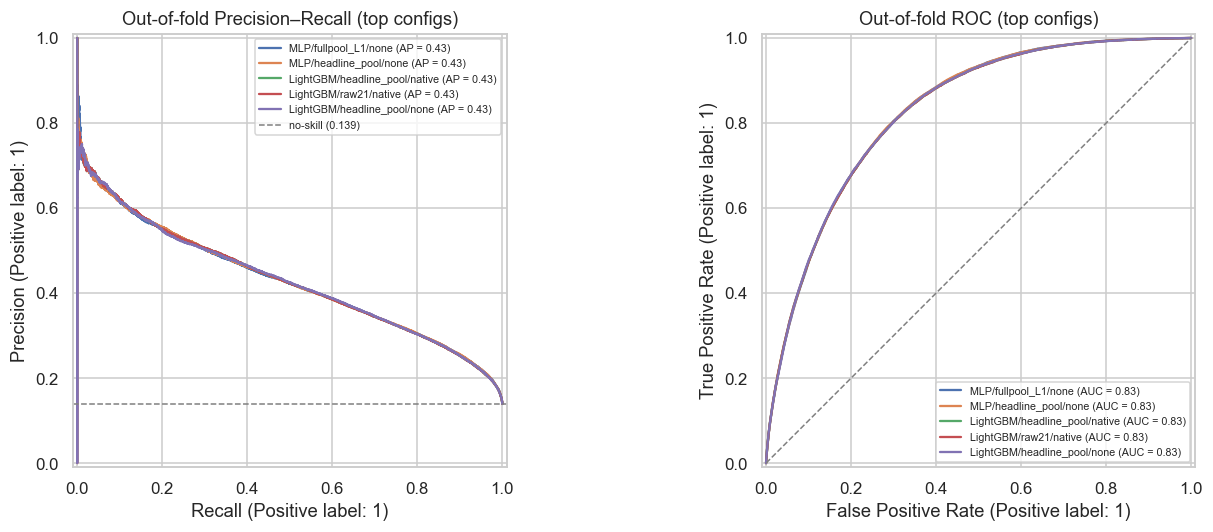

In [23]:
# OOF PR + ROC curves for the top-k configs
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
TOPK = 5
top_cfgs = master.head(TOPK)[["model","feature_set","imbalance"]].values.tolist()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for m, fs, imb in top_cfgs:
    oof = OOF_STORE.get((m, fs, imb))
    if oof is None: continue
    mask = ~np.isnan(oof)
    lbl = f"{m}/{fs}/{imb}"
    PrecisionRecallDisplay.from_predictions(y_train[mask], oof[mask], ax=ax[0], name=lbl)
    RocCurveDisplay.from_predictions(y_train[mask], oof[mask], ax=ax[1], name=lbl)
ax[0].axhline(prevalence, ls="--", c="grey", lw=1, label=f"no-skill ({prevalence:.3f})")
ax[0].set_title("Out-of-fold Precision–Recall (top configs)")
ax[1].plot([0,1],[0,1], ls="--", c="grey", lw=1)
ax[1].set_title("Out-of-fold ROC (top configs)")
ax[0].legend(fontsize=7, loc="upper right"); ax[1].legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nb06_oof_curves.png", dpi=110, bbox_inches="tight")
plt.show()

#### Interpretation — Feature & model screen

**Top of the leaderboard (non-exploratory):** MLP / `headline_pool` / `none` = **0.4309**; LightGBM / `headline_pool` / `none` = **0.4303**. The exploratory `fullpool_L1` tops the raw list at **0.4310** — but that is **+0.0001** over the interpretable `headline_pool`, i.e. a tie. The most elaborate feature machine in the notebook does not beat *raw features + one squared term*.

**Feature-mode effect is bias-dependent** (paired Δ vs raw21, sampling held at the carried `none`):

| family | headline_pool (BMI²) | fullpool_L1 | fullpool_EN |
|---|---|---|---|
| LogReg | +0.0152 | +0.0163 | +0.0137 |
| MLP | +0.0008 | +0.0009 | −0.0041 |
| LightGBM | +0.0000 | −0.0010 | −0.0087 |
| XGBoost | +0.0000 | −0.0022 | +0.0028 |
| RandomForest | −0.0010 | **−0.0196** | **−0.0372** |

Feature expansion / L1 selection **helps linear models** (which cannot synthesise BMI² themselves) and **hurts trees** (which split on BMI directly; extra correlated columns only add variance). For every family the gain over raw21 is captured by `headline_pool` alone; `fullpool` adds nothing beyond noise and is fragile on trees — hence its exploratory tag.

**Carried into the finalists:** `headline_pool` for the families that benefit (MLP, LightGBM, LogReg), `raw21` where expansion hurts (RandomForest). This convergence — hand-pick ≈ data-driven selection ≈ ceiling — is direct evidence that the bottleneck is the **data, not the feature set**.

**Closing the NB02 flag on `CholCheck` / `AnyHealthcare`.** NB02 (§8.1) deferred the
keep/drop call on these two healthcare-access indicators to here. Both are retained:
they enter every feature mode as part of `raw21`, and the in-fold selectors keep them
when free to drop them — `CholCheck` carries real weight (|coef| ≈ 0.23, among the
stronger terms), while `AnyHealthcare` survives with a near-zero coefficient (kept for
completeness, not signal). No §8 representation excludes them, so the question NB02
raised is settled empirically in favour of keeping both.

## 9. Best configuration per model & stacking potential

First a "results at a glance" view: each family's single best grid cell. Then the diversity analysis that motivates a possible stacking pick — ensembles gain from *uncorrelated errors*, so a family that scores lower but errs differently from the leaders can still earn a base-learner slot in NB07. Both rest on the out-of-fold predictions already collected on identical folds (leakage-free).

In [24]:
# best configuration per model (reporting view; NOT the finalist selector)
best_per_model = (master[(master["model"].isin(grid_models)) & (~master["exploratory"])]
                  .sort_values("pr_auc_mean", ascending=False)
                  .groupby("model", as_index=False).first()
                  .sort_values("pr_auc_mean", ascending=False).reset_index(drop=True))
best_per_model.to_csv(OUTPUT_DIR / "nb06_best_per_model.csv", index=False)

disp = pd.concat([best_per_model[["model","feature_set","imbalance","pr_auc_mean",
                                  "roc_auc_mean","brier_mean","fit_time"]],
                  pd.DataFrame([{"model":"— no-skill floor —","feature_set":"",
                                 "imbalance":"","pr_auc_mean":prevalence,
                                 "roc_auc_mean":0.5}])], ignore_index=True)
print("Best configuration per family (reporting view):")
print(disp.to_string(index=False))

Best configuration per family (reporting view):
             model   feature_set imbalance  pr_auc_mean  roc_auc_mean  brier_mean  fit_time
               MLP headline_pool      none     0.430896      0.829395    0.096846 39.410249
          LightGBM headline_pool    native     0.430497      0.827836    0.171102  7.070797
         LogReg-L2 headline_pool      none     0.420788      0.825531    0.097874  1.129424
         LogReg-EN headline_pool      none     0.420784      0.825530    0.097874  6.276141
           XGBoost headline_pool      none     0.405083      0.816431    0.100035 11.100565
      RandomForest         raw21      none     0.394751      0.806144    0.100907 82.732718
— no-skill floor —                             0.139330      0.500000         NaN       NaN


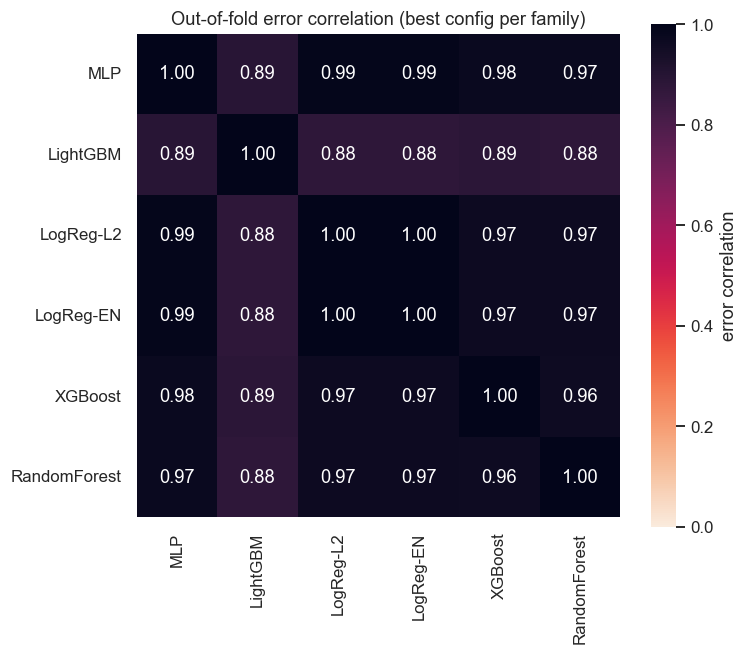

Mean off-diagonal error correlation: 0.945


In [25]:
# OOF error-correlation heatmap across each family's best config
best_keys = [(r["model"], r["feature_set"], r["imbalance"])
             for _, r in best_per_model.iterrows()]
# common rows present in all OOF arrays
err_mat = {}
for m, fs, imb in best_keys:
    oof = OOF_STORE.get((m, fs, imb))
    if oof is not None:
        err_mat[m] = y_train.values - oof          # residuals
err_df = pd.DataFrame(err_mat).dropna()
corr = err_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
            square=True, cbar_kws={"label":"error correlation"}, ax=ax)
ax.set_title("Out-of-fold error correlation (best config per family)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nb06_error_correlation.png", dpi=110, bbox_inches="tight")
plt.show()
print("Mean off-diagonal error correlation:",
      f"{corr.values[np.triu_indices_from(corr.values,1)].mean():.3f}")

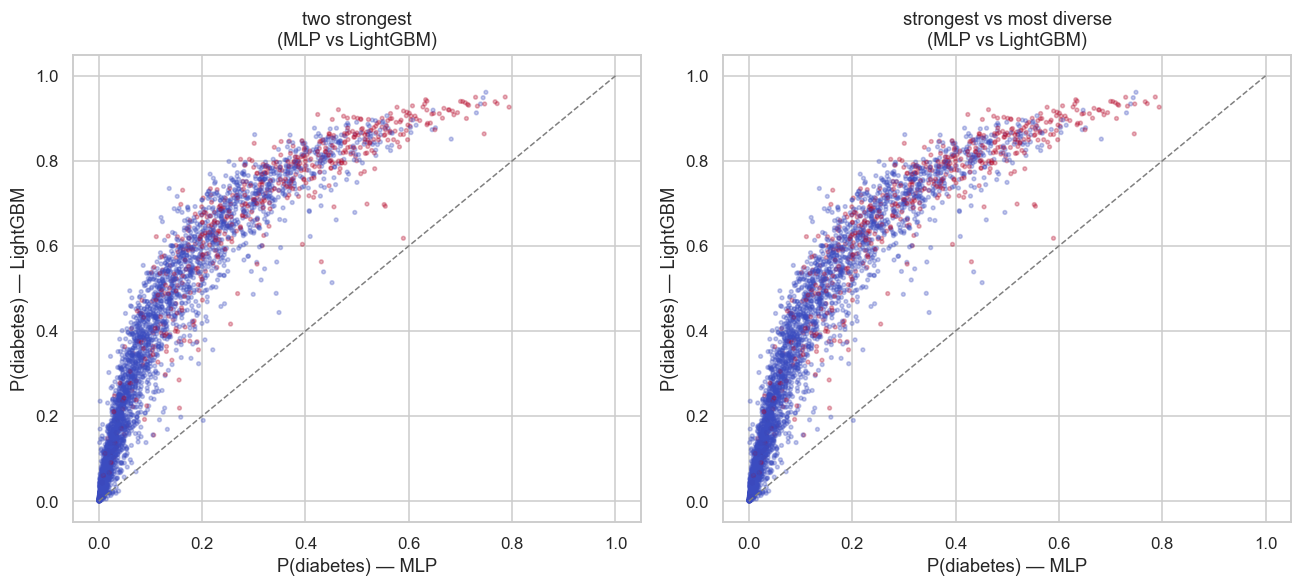

In [26]:
# disagreement scatter: two strongest models, plus strongest vs most-diverse
order = best_per_model["model"].tolist()
def oof_of(m):
    row = best_per_model[best_per_model["model"]==m].iloc[0]
    return OOF_STORE.get((row["model"], row["feature_set"], row["imbalance"]))

pairs = []
if len(order) >= 2:
    pairs.append((order[0], order[1], "two strongest"))
# strongest vs least-correlated partner
if len(corr) >= 2:
    least = corr[order[0]].drop(order[0]).idxmin()
    pairs.append((order[0], least, "strongest vs most diverse"))

fig, axes = plt.subplots(1, len(pairs), figsize=(6*len(pairs), 5.5), squeeze=False)
for ax, (a, b, title) in zip(axes[0], pairs):
    pa, pb = oof_of(a), oof_of(b)
    m = ~(np.isnan(pa) | np.isnan(pb))
    samp = np.random.RandomState(SEED).choice(np.where(m)[0],
            size=min(4000, m.sum()), replace=False)
    ax.scatter(pa[samp], pb[samp], c=y_train.values[samp], cmap="coolwarm",
               s=6, alpha=0.3)
    ax.plot([0,1],[0,1], ls="--", c="grey", lw=1)
    ax.set_xlabel(f"P(diabetes) — {a}"); ax.set_ylabel(f"P(diabetes) — {b}")
    ax.set_title(f"{title}\n({a} vs {b})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nb06_disagreement_scatter.png", dpi=110, bbox_inches="tight")
plt.show()

In [27]:
# ---------------------------------------------------------------------
# 9b. Diversity across ALL families + stacking screen.
# The correlation heatmap above covers only the 6 strong grid families (all
# ~0.945). The learners with the MOST different inductive bias — KNN
# (distance-based) and GaussianNB (generative) — were dropped at §5 for low
# PR-AUC and never entered the OOF store. They are the only plausible
# *decorrelated* stacking partners, so we compute their OOF here and test,
# results-driven, whether ANY stack beats the best single finalist by > 1 SE.
#
# NOTE: stacking on stored OOF is mildly optimistic (the meta-learner sees all
# out-of-fold rows); a gain here is a HYPOTHESIS for NB07, and NB08 on the
# frozen test set is the only unbiased check.
# ---------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression as _MetaLR

for name, factory in [("KNN", f_knn), ("GaussianNB", f_gnb), ("SVM-Nystroem", f_svm_nys)]:
    if (name, "raw21", "none") in OOF_STORE:
        continue
    r = evaluate_config(factory, X_train_raw, name, "none",
                        feature_set="raw21", log=False)
    if "error" not in r:
        OOF_STORE[(name, "raw21", "none")] = r["oof"]
        RECORDS.append({**r, "exploratory": True})
        print(f"  diversity probe {name:11s} PR={r['pr_mean']:.4f}")
    else:
        print(f"  diversity probe {name}: {r['error']}")

# finalist OOF keys (LightGBM finalist = none, per §6) + the two probes
probe_keys = {
    "MLP":        ("MLP",        "headline_pool", "none"),
    "LightGBM":   ("LightGBM",   "headline_pool", "none"),
    "LogReg-L2":  ("LogReg-L2",  "headline_pool", "none"),
    "KNN":        ("KNN",        "raw21",         "none"),
    "GaussianNB": ("GaussianNB", "raw21",         "none"),
    "SVM-Nystroem": ("SVM-Nystroem", "raw21", "none"),
}
probe_keys = {l: k for l, k in probe_keys.items() if k in OOF_STORE}
err_df = pd.DataFrame({l: y_train.values - OOF_STORE[k]
                       for l, k in probe_keys.items()}).dropna()
corr_all = err_df.corr()
print("\nError correlation incl. diversity probes:")
print(corr_all.round(3).to_string())
off = corr_all.values[np.triu_indices_from(corr_all.values, 1)]
print(f"min off-diagonal correlation: {off.min():.3f} "
      f"({corr_all.stack().drop([(i,i) for i in corr_all.index]).idxmin()})")

def _pr_folds(oof):
    pr = []
    for tr, va in splits:
        m = ~np.isnan(oof[va])
        pr.append(average_precision_score(y_train.values[va][m], oof[va][m]))
    return np.array(pr)

def _stack_folds(labels):
    Z = np.column_stack([OOF_STORE[probe_keys[l]] for l in labels])
    ok = ~np.isnan(Z).any(axis=1); pr = []
    for tr, va in splits:
        trm, vam = tr[ok[tr]], va[ok[va]]
        meta = _MetaLR(max_iter=1000).fit(Z[trm], y_train.values[trm])
        p = meta.predict_proba(Z[vam])[:, 1]
        pr.append(average_precision_score(y_train.values[vam], p))
    return np.array(pr)

base = [l for l in ("MLP", "LightGBM") if l in probe_keys]
best_single_lbl = max(base, key=lambda l: _pr_folds(OOF_STORE[probe_keys[l]]).mean())
best_single = _pr_folds(OOF_STORE[probe_keys[best_single_lbl]])
print(f"\nStacking screen — best single base: {best_single_lbl} "
      f"PR={best_single.mean():.4f}")

# (1) Does combining the two leaders beat the best single model?
base_stack = _stack_folds(base)
d_base = paired_delta(base_stack, best_single)
print(f"  base stack {str(base):37s} PR={base_stack.mean():.4f}  "
      f"Δ vs best single={d_base['mean']:+.4f} (1SE={d_base['se']:.4f})  "
      f"{'beats best single (>1 SE)' if d_base['mean'] - d_base['se'] > 0 else 'within noise'}")

# (2) Does any DIVERSITY learner add value BEYOND the two-leader stack?
#     This — not (base vs best single) — is what earns a separate slot in NB07.
DIVERSITY_ADDS_VALUE, stack_pick = False, None
for x in ("LogReg-L2", "KNN", "GaussianNB", "SVM-Nystroem"):
    if x not in probe_keys:
        continue
    pr = _stack_folds(base + [x]); d = paired_delta(pr, base_stack)
    gain = d["mean"] - d["se"]            # 1-SE lower bound vs the base stack
    verdict = "ADDS over base stack (>1 SE)" if gain > 0 else "no gain over base stack"
    print(f"  + {x:11s} PR={pr.mean():.4f}  Δ vs base stack={d['mean']:+.4f} "
          f"(1SE={d['se']:.4f})  {verdict}")
    if gain > 0:
        DIVERSITY_ADDS_VALUE, stack_pick = True, x
print(f"\n=> a diversity learner beats the two-leader stack: {DIVERSITY_ADDS_VALUE}"
      + (f"  (via {stack_pick})" if stack_pick else ""))

  diversity probe KNN         PR=0.3659
  diversity probe GaussianNB  PR=0.3409
  diversity probe SVM-Nystroem PR=0.4229

Error correlation incl. diversity probes:
                MLP  LightGBM  LogReg-L2    KNN  GaussianNB  SVM-Nystroem
MLP           1.000     0.992      0.990  0.971       0.730         0.987
LightGBM      0.992     1.000      0.987  0.968       0.728         0.984
LogReg-L2     0.990     0.987      1.000  0.965       0.729         0.987
KNN           0.971     0.968      0.965  1.000       0.728         0.963
GaussianNB    0.730     0.728      0.729  0.728       1.000         0.719
SVM-Nystroem  0.987     0.984      0.987  0.963       0.719         1.000
min off-diagonal correlation: 0.719 (('GaussianNB', 'SVM-Nystroem'))

Stacking screen — best single base: MLP PR=0.4309
  base stack ['MLP', 'LightGBM']                   PR=0.4349  Δ vs best single=+0.0040 (1SE=0.0003)  beats best single (>1 SE)
  + LogReg-L2   PR=0.4349  Δ vs base stack=-0.0000 (1SE=0.0000)  no gai

#### Interpretation — Diversity & stacking

Two readings of the same evidence, kept apart so the numbers don't look contradictory.

**The error-correlation heatmap (above)** is built from each family's *best-scoring* config. For five of the six families that is `none`, and they sit at ~0.97–1.00 with each other — they make almost exactly the same mistakes. LightGBM is the apparent outlier (~0.88 with the rest), but only because *its* best-scoring config is `native`, which inflates its probabilities (the decalibration from §6) and so re-shapes its residuals — it still *ranks* people almost identically. At the `none` config actually carried forward (the one used in the stacking screen below), LightGBM is ~0.99 error-correlated with MLP and the others too. So the conclusion holds under either reading: **the six strong families make highly correlated errors.** The linear pair (LogReg-EN ≈ LogReg-L2) is identical by construction.

**The stacking screen** then asks two separate questions on out-of-fold predictions (all at `none`). First, does combining the two leaders help at all? The MLP+LightGBM stack reaches PR-AUC ≈ **0.4349** — about **+0.004** over the best single model, the highest out-of-fold number anywhere in this notebook — clearing the 1-SE bar on the (optimistic) fold SE. Second, does any *third* learner improve on that two-model stack? To find genuine diversity the screen adds three structurally different probes — KNN (distance-based), GaussianNB (generative), SVM-Nystroem (kernel). Only **GaussianNB is truly decorrelated** (~0.73 with the leaders); KNN (~0.97) and even SVM-Nystroem (~0.98, the strongest probe at PR-AUC 0.423) are as correlated as the grid families. And **none of them improves the stack**: LogReg/KNN/GaussianNB leave it essentially unchanged, and SVM-Nystroem actually *lowers* it → `DIVERSITY_ADDS_VALUE = False`.

**What this means.** The MLP+LightGBM stack is the default candidate — both are already finalists, so NB07 can build it. But because the two are ~0.99 error-correlated at `none`, little is expected from combining them on first principles: the +0.004 is small, rests on the optimistic out-of-fold SE, and may vanish on the frozen test set — and after tuning in NB07 it does (the stack adds only +0.0002 and is not used). That even a strong, genuinely different-mechanism model (SVM) stays ~0.98 error-correlated is the sharpest evidence in the notebook that **the limit is the data, not the model.** All of this rests on out-of-fold stacking, which is mildly optimistic; NB08 on the frozen test set is the only unbiased check.

## 10. Robustness & sanity

Four quick checks before committing finalists: is the top ranking stable or inside the fold-noise band; do high-capacity models overfit (train vs OOF gap); is each family's runtime compatible with tuning in NB07; and how does calibration (Brier) track discrimination.

In [28]:
# (a) ranking stability: is #1 separable from the chasing pack within 1*SE?
top = master.iloc[0]
se_top = top["pr_auc_std"] / np.sqrt(N_FOLDS)
within = master[master["pr_auc_mean"] >= top["pr_auc_mean"] - se_top]
print(f"Top config: {top['model']}/{top['feature_set']}/{top['imbalance']} "
      f"PR={top['pr_auc_mean']:.4f} (SE={se_top:.4f})")
print(f"Configs within 1*SE of the top: {len(within)}")
print(within[["model","feature_set","imbalance","pr_auc_mean"]].to_string(index=False))

Top config: MLP/fullpool_L1/none PR=0.4310 (SE=0.0035)
Configs within 1*SE of the top: 9
   model   feature_set imbalance  pr_auc_mean
     MLP   fullpool_L1      none     0.430960
     MLP headline_pool      none     0.430896
LightGBM headline_pool    native     0.430497
LightGBM         raw21    native     0.430497
LightGBM headline_pool      none     0.430278
LightGBM         raw21      none     0.430278
     MLP         raw21      none     0.430077
LightGBM   fullpool_L1      none     0.429295
LightGBM   fullpool_L1    native     0.429171


In [29]:
# (b) OOF sanity check for the top configs (honest read; full refit gap is NB07's job)
print("Out-of-fold PR-AUC (top configs):")
for m, fs, imb in master.head(TOPK)[["model","feature_set","imbalance"]].values:
    oof = OOF_STORE.get((m, fs, imb))
    if oof is None: continue
    mask = ~np.isnan(oof)
    oof_pr = average_precision_score(y_train[mask], oof[mask])
    print(f"  {m:14s} {fs:14s} {imb:10s}  OOF PR={oof_pr:.4f}")
print("(full in-sample refit gap is computed in NB07; here OOF is the honest read)")

Out-of-fold PR-AUC (top configs):
  MLP            fullpool_L1    none        OOF PR=0.4293
  MLP            headline_pool  none        OOF PR=0.4300
  LightGBM       headline_pool  native      OOF PR=0.4299
  LightGBM       raw21          native      OOF PR=0.4299
  LightGBM       headline_pool  none        OOF PR=0.4297
(full in-sample refit gap is computed in NB07; here OOF is the honest read)


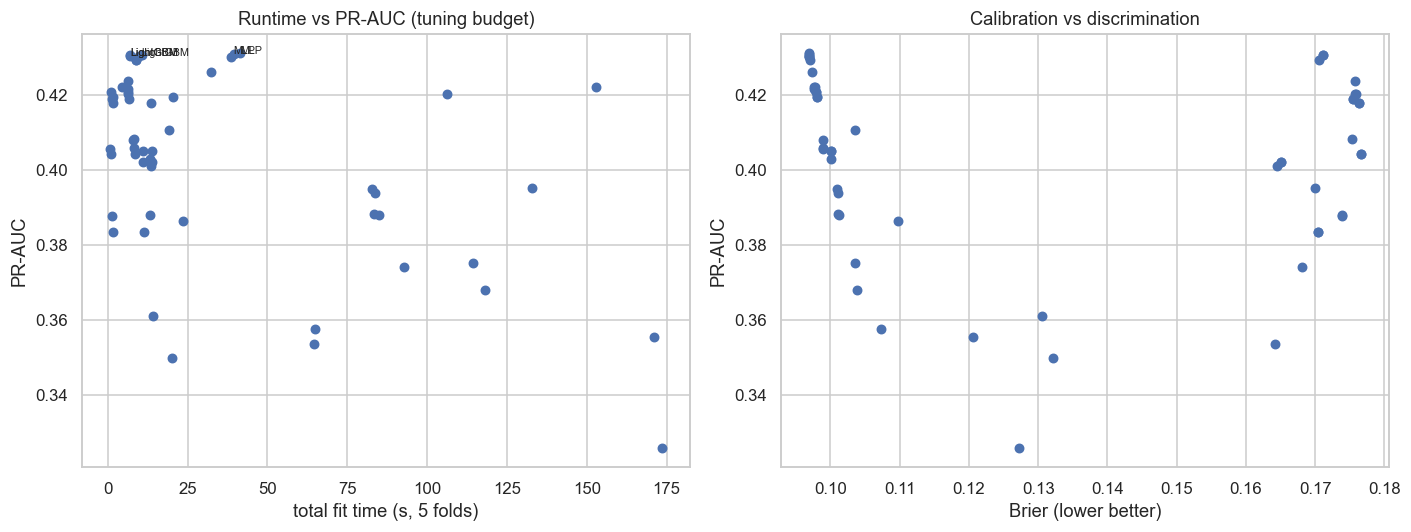

In [30]:
# (c) runtime budget + (d) calibration vs discrimination
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(master["fit_time"], master["pr_auc_mean"], s=30)
for _, r in master.head(TOPK).iterrows():
    ax[0].annotate(r["model"], (r["fit_time"], r["pr_auc_mean"]), fontsize=7)
ax[0].set_xlabel("total fit time (s, 5 folds)"); ax[0].set_ylabel("PR-AUC")
ax[0].set_title("Runtime vs PR-AUC (tuning budget)")
ax[1].scatter(master["brier_mean"], master["pr_auc_mean"], s=30)
ax[1].set_xlabel("Brier (lower better)"); ax[1].set_ylabel("PR-AUC")
ax[1].set_title("Calibration vs discrimination")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nb06_robustness.png", dpi=110, bbox_inches="tight")
plt.show()

#### Interpretation — Robustness & sanity

**The top config is not cleanly separable from the field.** Nine configurations fall within 1·SE of the leader — the "#1" is a band, not a winner, exactly what a data-limited ceiling looks like. Ranking is stable in the sense that the *same families* (MLP, LightGBM) sit at the top across folds, but the absolute gaps are within noise, so finalist selection rests on calibration, runtime, and interpretability rather than a decimal of PR-AUC.

**Calibration vs discrimination (right panel).** The configurations split into two vertical bands — well-calibrated (Brier ≈ 0.10) and poorly-calibrated (Brier ≈ 0.17) — and **both bands reach the same top PR-AUC (~0.43)**: good ranking is available with good *and* with bad probabilities, so ranking quality does not dictate calibration. From the leaderboard, the poorly-calibrated band is the `native` (reweighted) configs and the well-calibrated band is `none`; `none` therefore buys the same ranking with trustworthy probabilities — the basis for carrying it.

**Runtime (left panel).** The top-PR-AUC configurations all sit in the fast left cluster, so the finalists (LogReg, LightGBM, MLP) are cheap to fit and unconstrained for tuning in NB07; the slow points on the right are RandomForest (especially with SMOTENC) and the full-pool selector. Per the leaderboard, fit times across *all* families tried run from ~1 s (LogReg) to ~200 s (SVM, §5) — roughly three orders of magnitude — but every finalist sits at the cheap end.

## 11. Finalist selection

In [33]:
# ---------------------------------------------------------------------
# 11. Finalist selection (rule fixed in §4, before results were seen).
# Three tuning finalists, each on a distinct, explicit basis:
#   (1) PERFORMANCE  — the 1*SE tie-band (families within 1 SE of the top).
#   (2) INTERPRETABILITY — best linear family (LogReg-*), carried for the
#       clinical use-case though below the band. Labelled; not a perf claim.
#   (3) A separate STACKING candidate is added ONLY if a diversity learner beat
#       the two-leader stack by >1 SE (DIVERSITY_ADDS_VALUE); on these results none does.
# All finalist configs use imbalance=none (§6). native decalibrates -> excluded.
# ---------------------------------------------------------------------
eligible = master[(master["model"].isin(grid_models)) & (~master["exploratory"])].copy()
eligible = eligible[eligible["imbalance"] == "none"]            # §6 carry decision: none
perf_finalists, tie_band = select_finalists(eligible, k_extra=1)  # top + 1 more family

print("Tie-band (within 1*SE of the top):")
print(tie_band[["model","feature_set","imbalance","pr_auc_mean","fit_time"]].to_string(index=False))

finalist_rows, seen = [], set()
for _, r in perf_finalists.iterrows():
    d = r.to_dict(); d["role"] = "tuning_finalist"
    d["reason"] = "performance (tie-band rule)"
    finalist_rows.append(d); seen.add(r["model"])

# (2) interpretability finalist: best linear family not already chosen
lin = (eligible[eligible["model"].str.startswith("LogReg")]
       .sort_values("pr_auc_mean", ascending=False))
if len(lin) and lin.iloc[0]["model"] not in seen:
    d = lin.iloc[0].to_dict(); d["role"] = "tuning_finalist"
    d["reason"] = "interpretability (transparent linear model for clinical use)"
    finalist_rows.append(d); seen.add(lin.iloc[0]["model"])

# (3) optional stacking candidate (separate, NOT one of the three) — results-driven.
#     Take the EXACT config the §9 screen used (probe_keys); it may be a non-grid
#     diversity probe (KNN / GaussianNB / SVM), so look in RECORDS, not eligible.
if DIVERSITY_ADDS_VALUE and stack_pick and stack_pick not in seen:
    m, fs, imb = probe_keys[stack_pick]
    cand = records_to_df([r for r in RECORDS
                          if r["model"] == m and r["feature_set"] == fs
                          and r["imbalance"] == imb])
    if len(cand):
        d = cand.iloc[0].to_dict(); d["role"] = "stacking_candidate"
        d["reason"] = "diversity pick for stacking (cleared 1-SE bar in §9)"
        finalist_rows.append(d)

final_df = pd.DataFrame(finalist_rows)[
    ["model","feature_set","imbalance","pr_auc_mean","roc_auc_mean","brier_mean",
     "fit_time","role","reason"]]
perf_df  = final_df[final_df["role"] == "tuning_finalist"]
stack_df = final_df[final_df["role"] == "stacking_candidate"]
print("\nTuning finalists for NB07 (performance + interpretability):")
print(perf_df.drop(columns="role").to_string(index=False))
if len(stack_df):
    print("\nStacking candidate (separate, not part of the three):")
    print(stack_df.drop(columns="role").to_string(index=False))
elif d_base["mean"] - d_base["se"] > 0:
    print(f"\nStacking recipe for NB07: {' + '.join(base)} "
          f"(OOF +{d_base['mean']:.4f} over best single, >1 SE — promising but OOF-optimistic; "
          f"validate on the NB08 test set). No extra diversity learner needed.")
else:
    print("\nNo stacking benefit found in §9.")

Tie-band (within 1*SE of the top):
   model   feature_set imbalance  pr_auc_mean  fit_time
LightGBM headline_pool      none     0.430278  7.066791
     MLP headline_pool      none     0.430896 39.410249
LightGBM         raw21      none     0.430278  9.619400
     MLP         raw21      none     0.430077 38.437812

Tuning finalists for NB07 (performance + interpretability):
    model   feature_set imbalance  pr_auc_mean  roc_auc_mean  brier_mean  fit_time                                                       reason
      MLP headline_pool      none     0.430896      0.829395    0.096846 39.410249                                  performance (tie-band rule)
 LightGBM headline_pool      none     0.430278      0.828500    0.096905  7.066791                                  performance (tie-band rule)
LogReg-L2 headline_pool      none     0.420788      0.825531    0.097874  1.129424 interpretability (transparent linear model for clinical use)

Stacking recipe for NB07: MLP + LightGBM (OOF +

#### Interpretation — Finalist selection

Three finalists advance to NB07 tuning, each on an explicit and distinct basis:

- **MLP — performance.** Top of the 1·SE tie-band (`headline_pool`, `none`, ~0.4309), best-calibrated of the strong models.
- **LightGBM — performance + practicality.** Statistically tied with MLP (~0.4303), ~4× faster, native categorical handling, well-calibrated under `none`.
- **LogReg — interpretability.** ~3 SE below the tie-band, so **not a performance pick** — carried because a transparent linear model is valuable for a clinical risk score, and §8 shows it captures the full feature signal once BMI² is added.

All three use `imbalance = none` (§6). No separate stacking learner is added: the §9 screen showed that an MLP+LightGBM stack edges the best single model (≈ 0.4349, +0.004 on optimistic OOF — and since the two are ~0.99 error-correlated, this small edge may not survive the NB08 test set), but no *additional* base learner improves on that two-model stack — not LogReg/KNN/GaussianNB, and not even SVM-Nystroem, the strongest different-mechanism candidate, which is ~0.98 error-correlated with the leaders and actually *lowers* the stack. Nothing is decorrelated enough to justify a fourth slot. The stack itself needs no extra finalist: both its base learners are already carried, so NB07 can build and confirm it. The "best single number," `fullpool_L1` at 0.4310, is not promoted: it is exploratory and +0.0001 over the interpretable set.

## 12. Persist outputs

Every successful CV run is already in the shared `outputs/results.csv` ledger (`notebook="nb06"`). Here we write the NB06-specific artifacts: the leaderboard, the best-per-model view, the finalist set, the per-config out-of-fold predictions (for the NB07 stack), and the skip log.

In [ ]:
# combined OOF predictions for the finalists (for NB07 stacking)
fold_of = np.full(len(y_train), -1)
for k, (_, va) in enumerate(splits):
    fold_of[va] = k

oof_frames = []
for r in finalist_rows:
    key = (r["model"], r["feature_set"], r["imbalance"])
    oof = OOF_STORE.get(key)
    if oof is None: continue
    mask = ~np.isnan(oof)
    oof_frames.append(pd.DataFrame({
        "row_index": y_train.index.values[mask],
        "fold_id": fold_of[mask],
        "y_true": y_train.values[mask], "y_proba": oof[mask],
        "model": r["model"], "feature_set": r["feature_set"],
        "imbalance": r["imbalance"]}))
if oof_frames:
    pd.concat(oof_frames, ignore_index=True).to_parquet(
        OUTPUT_DIR / "nb06_finalist_oof.parquet")

# finalist metadata (csv + json)
final_df.to_csv(OUTPUT_DIR / "nb06_finalists.csv", index=False)

# stacking recipe for NB07: the §9b base stack (MLP+LightGBM) beat the best single by >1 SE
stacking_recipe = ({"base_learners": base, "feature_set": "headline_pool", "imbalance": "none",
                    "status": f"OOF-promising (+{d_base['mean']:.4f} over best single, >1 SE); "
                              f"validate on the NB08 test set"}
                   if d_base["mean"] - d_base["se"] > 0 else None)

with open(OUTPUT_DIR / "nb06_finalists.json", "w") as f:
    json.dump({"seed": SEED, "n_folds": N_FOLDS, "prevalence": prevalence,
               "tuning_finalists": [r for r in finalist_rows if r.get("role") == "tuning_finalist"],
               "stacking_candidate": [r for r in finalist_rows if r.get("role") == "stacking_candidate"],
               "stacking_recipe": stacking_recipe,
               "selection_rule": "1*SE noise band + family diversity; the stacking candidate is "
                                 "separate and NOT counted among the 1-3 tuning finalists",
               "note": "no tuning in NB06; test set frozen; NB08 is the unbiased check"},
              f, indent=2, default=float)

# skip log
pd.DataFrame(SKIPPED).to_csv(OUTPUT_DIR / "nb06_skipped_configs.csv", index=False)

print("Saved to", OUTPUT_DIR.relative_to(PROJECT_ROOT))
for p in sorted(OUTPUT_DIR.glob("nb06_*")):
    print("  ", p.name)

Saved to outputs\nb06
   nb06_best_per_model.csv
   nb06_disagreement_scatter.png
   nb06_error_correlation.png
   nb06_family_screen.csv
   nb06_finalist_oof.parquet
   nb06_finalists.csv
   nb06_finalists.json
   nb06_imbalance_ablation.csv
   nb06_leaderboard.csv
   nb06_oof_curves.png
   nb06_robustness.png
   nb06_skipped_configs.csv


## 13. Summary & outlook

**What the funnel established, in order.**

1. **Imbalance → `none`.** A ten-strategy ablation and a per-family screen agree: no correction strategy provides a robust, useful gain over `none`. `native` edges it on ranking (+0.0002, within noise) but decalibrates (Brier 0.097 → 0.171); `SMOTE` is significantly-but-marginally worse (−0.0027, worse in 5/5 folds) because interpolating binary indicators invents unreal profiles; `SMOTENC` is worst. Imbalance is handled by the **metric and threshold**, not by resampling.
2. **The literature's 0.9+ scores are leakage** (§7): SMOTE-before-split, the pre-balanced 50/50 set, and accuracy-on-resampled-data. Holding the protocol honest is why the leakage-free screening plateaus around 0.43 PR-AUC.
3. **Features → BMI² and nothing more.** Expansion helps linear models, hurts trees, and the in-fold L1/EN selectors' strongest coefficients concentrate on the same dominant signals as `headline_pool` (they keep 39/45 features, but the extra ones add only weak, redundant terms) — feature engineering is not the bottleneck.
4. **Models → a tie at the ceiling.** MLP and LightGBM lead within noise; nine configs fall inside 1·SE.
5. **Stacking → an MLP+LightGBM ensemble**, nothing more. The two leaders combine to ≈ 0.4349 (+0.004 over the best single — the notebook's top OOF number, but optimistic and, given their ~0.99 error correlation, likely to shrink on the test set), but no extra learner improves on that pair. Even the strongest different-mechanism candidate, SVM-Nystroem, is ~0.98 error-correlated with the leaders and *lowers* the stack; KNN and GaussianNB add nothing either. Both base learners are already finalists, so NB07 can build the stack; the OOF gain is small and optimistic, and NB08 is the test.

**Finalists for NB07:** **MLP** and **LightGBM** (performance), **LogReg** (interpretability) — all at `imbalance = none` and `headline_pool`.

**The honest plateau.** Every axis — model, feature set, imbalance treatment — lands around ~0.43 PR-AUC. The dominant limit is **label structure**: undiagnosed diabetics are labelled negative (positive-unlabelled / label noise), so the plateau reflects what the labels can support far more than the choice of algorithm. Tuning in NB07 may nudge it slightly; **NB08 on the frozen test set is the only unbiased estimate** — these screening numbers are optimistic by construction.

## References

### Imbalance methods
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research, 16*, 321–357.
- Han, H., Wang, W.-Y., & Mao, B.-H. (2005). Borderline-SMOTE: A new over-sampling method in imbalanced data sets learning. *Advances in Intelligent Computing (ICIC 2005), LNCS 3644*, 878–887.
- He, H., Bai, Y., Garcia, E. A., & Li, S. (2008). ADASYN: Adaptive synthetic sampling approach for imbalanced learning. *IEEE IJCNN 2008*, 1322–1328.
- Batista, G. E. A. P. A., Prati, R. C., & Monard, M. C. (2004). A study of the behavior of several methods for balancing machine learning training data. *ACM SIGKDD Explorations Newsletter, 6*(1), 20–29.

### Evaluation & why imbalance correction is not justified here
- van den Goorbergh, R., van Smeden, M., Timmerman, D., & Van Calster, B. (2022). The harm of class imbalance corrections for risk prediction models: illustration and simulation using logistic regression. *Journal of the American Medical Informatics Association, 29*(9), 1525–1534.
- Blagus, R., & Lusa, L. (2013). SMOTE for high-dimensional class-imbalanced data. *BMC Bioinformatics, 14*, 106.
- Elor, Y., & Averbuch-Elor, H. (2022). To SMOTE, or not to SMOTE? *arXiv:2201.08528*.
- Saito, T., & Rehmsmeier, M. (2015). The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets. *PLOS ONE, 10*(3), e0118432.
- Kapoor, S., & Narayanan, A. (2023). Leakage and the reproducibility crisis in machine-learning-based science. *Patterns, 4*(9), 100804.
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1–21.

### Methodology
- Bengio, Y., & Grandvalet, Y. (2004). No unbiased estimator of the variance of K-fold cross-validation. *Journal of Machine Learning Research, 5*, 1089–1105. — `SE = sd/√k` is optimistic under fold dependence.